# Clasificador de Residuos con Deep Learning

## Integrantes
- Jean Lucas Nova Garcia  
- Yovani Andres Tarazona Castellanos  
- Maria Lucero Gomez Pico  

## Objetivo
Desarrollar un modelo capaz de clasificar imágenes de residuos en 6 categorías:
- Vidrio
- Papel
- Cartón
- Plástico
- Metal
- Orgánico

Utilizando técnicas de Machine Learning y Deep Learning, comparando distintos modelos para identificar el de mejor desempeño.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

In [2]:
data_original = "/kaggle/input/datasets/sumn2u/garbage-classification-v2/original"
data_256 = "/kaggle/input/datasets/sumn2u/garbage-classification-v2/standardized_256"

## Verificación de categorías disponibles

In [3]:
categorias_original = sorted(os.listdir(data_original))
categorias_256 = sorted(os.listdir(data_256))

print("Original:", categorias_original)
print("256x256:", categorias_256)

Original: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
256x256: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


In [4]:
categorias_validas = [
    "glass",
    "paper",
    "cardboard",
    "plastic",
    "metal",
    "biological"
]

## Análisis de distribución de imágenes por categoría

In [5]:
conteo_original = []
conteo_256 = []

for cat in categorias_validas:
    conteo_original.append(len(os.listdir(os.path.join(data_original, cat))))
    conteo_256.append(len(os.listdir(os.path.join(data_256, cat))))

df_conteo = pd.DataFrame({
    "Categoría": categorias_validas,
    "Original": conteo_original,
    "256x256": conteo_256
})

df_conteo

,Categoría,Original,256x256
0,glass,1736,1736
1,paper,1336,1336
2,cardboard,1411,1411
3,plastic,1597,1597
4,metal,930,930
5,biological,699,699


### Comparación entre dataset original y estandarizado

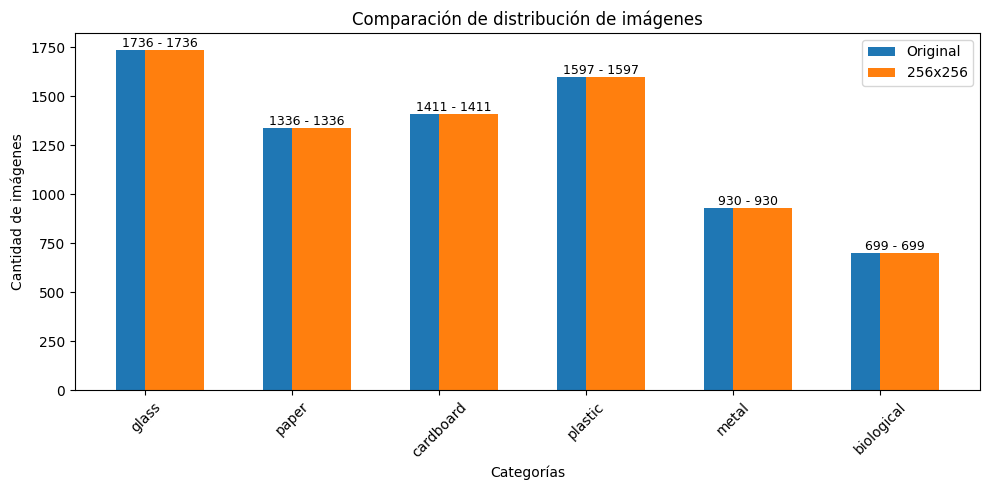

In [6]:
x = np.arange(len(categorias_validas))
plt.figure(figsize=(10,5))
barras1 = plt.bar(x, conteo_original, width=0.4, label="Original")
barras2 = plt.bar(x + 0.2, conteo_256, width=0.4, label="256x256")

for i in range(len(x)):
    y1 = conteo_original[i]
    y2 = conteo_256[i] 
    xpos = x[i] + 0.1
    ypos = max(y1, y2)
    plt.text(xpos, ypos,
             f'{y1} - {y2}',
             ha='center', va='bottom', fontsize=9)

plt.xticks(x, categorias_validas, rotation=45)
plt.xlabel("Categorías")
plt.ylabel("Cantidad de imágenes")
plt.title("Comparación de distribución de imágenes")
plt.legend()

plt.tight_layout()
plt.show()

### Distribución porcentual

In [7]:
total_original = sum(conteo_original)
total_256 = sum(conteo_256)

porc_original = [(x / total_original) * 100 for x in conteo_original]
porc_256 = [(x / total_256) * 100 for x in conteo_256]

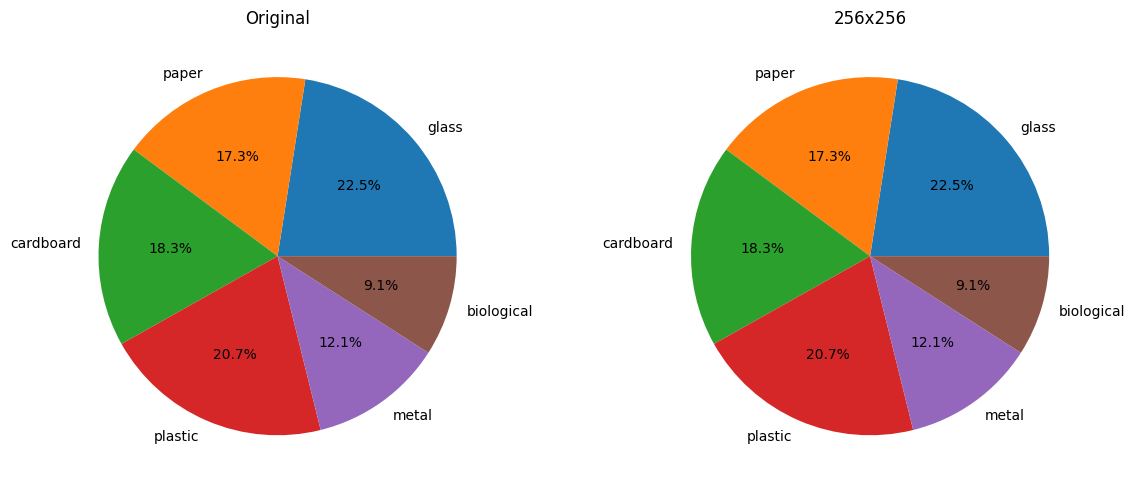

In [8]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.pie(porc_original, labels=categorias_validas, autopct='%1.1f%%')
plt.title("Original")

plt.subplot(1,2,2)
plt.pie(porc_256, labels=categorias_validas, autopct='%1.1f%%')
plt.title("256x256")

plt.tight_layout()
plt.show()

## Análisis de dimensiones de imágenes

In [9]:
altos_original = []
anchos_original = []

altos_256 = []
anchos_256 = []

for cat in categorias_validas:
    ruta_o = os.path.join(data_original, cat)
    ruta_256 = os.path.join(data_256, cat)
    
    img_o = Image.open(os.path.join(ruta_o, os.listdir(ruta_o)[0]))
    img_256 = Image.open(os.path.join(ruta_256, os.listdir(ruta_256)[0]))
    
    ancho_o, alto_o = img_o.size
    ancho_256, alto_256 = img_256.size
    
    altos_original.append(alto_o)
    anchos_original.append(ancho_o)
    
    altos_256.append(alto_256)
    anchos_256.append(ancho_256)

print("Original:", altos_original, anchos_original)
print("256x256:", altos_256, anchos_256)

Original: [300, 384, 500, 225, 289, 183] [225, 512, 500, 225, 289, 275]
256x256: [256, 256, 256, 256, 256, 256] [256, 256, 256, 256, 256, 256]


## Visualización de ejemplos por categoría

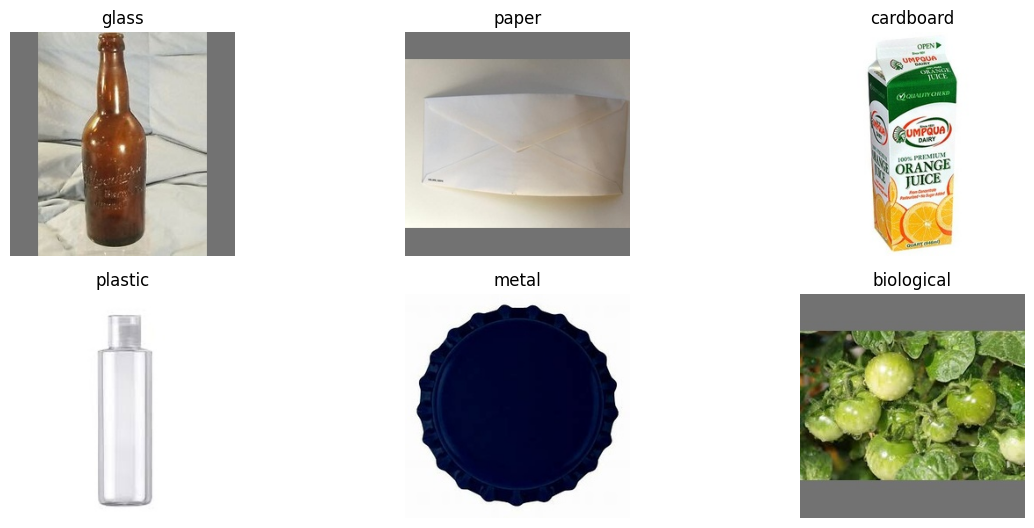

In [10]:
plt.figure(figsize=(12,8))

n = len(categorias_original)

for i, cat in enumerate(categorias_validas):
    ruta = os.path.join(data_256, cat)
    img = Image.open(os.path.join(ruta, os.listdir(ruta)[0]))
    
    plt.subplot(3,3,i+1) 
    plt.imshow(img)
    plt.title(cat)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Análisis de patrones visuales

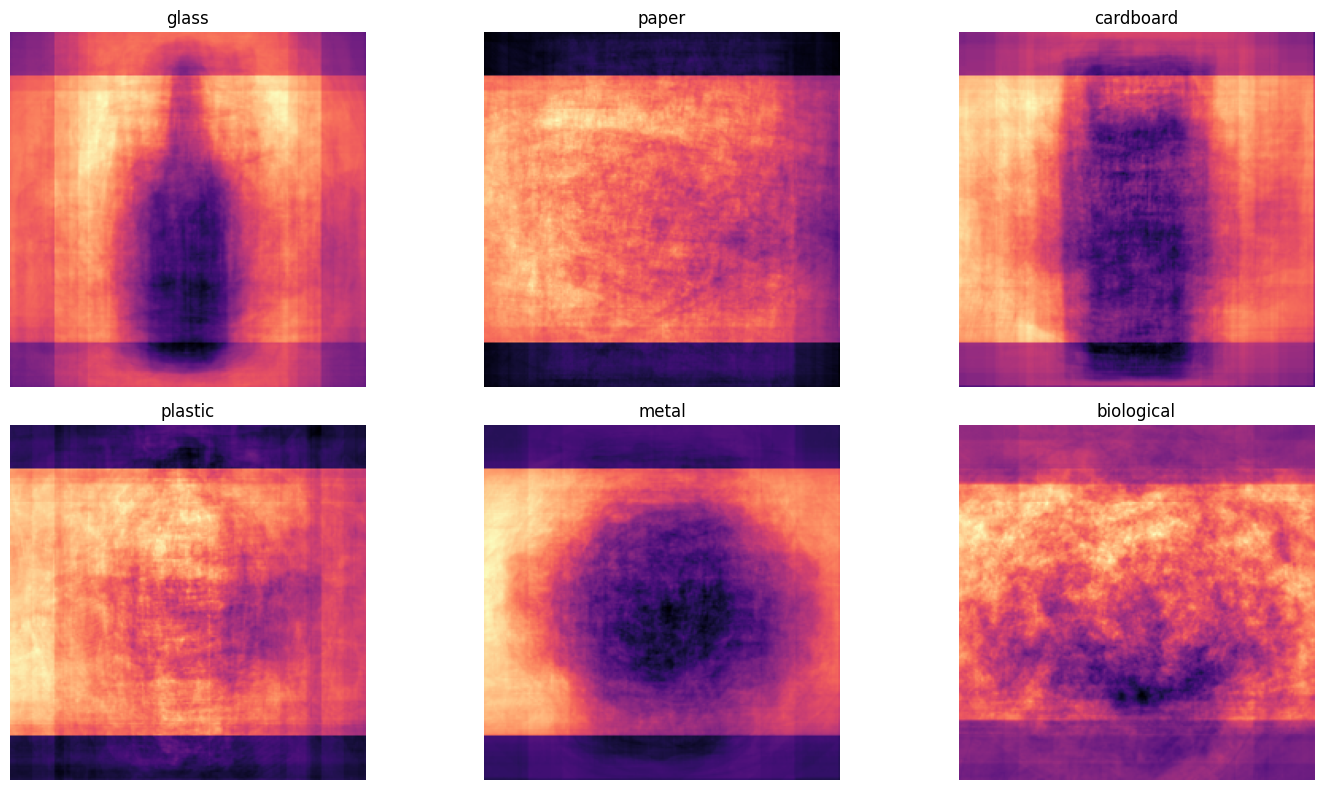

In [11]:
import cv2

categorias = ["glass", "paper", "cardboard", "plastic", "metal", "biological"]

plt.figure(figsize=(15, 8))

for i, cat in enumerate(categorias):
    ruta_cat = os.path.join(data_256, cat)
    fotos = [f for f in os.listdir(ruta_cat) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    
    muestra = fotos[:150]
    suma_pixeles = np.zeros((224, 224), dtype=np.float32)

    for nombre in muestra:
        img = cv2.imread(os.path.join(ruta_cat, nombre), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            suma_pixeles += cv2.resize(img, (224, 224))
            
    heatmap = suma_pixeles / len(muestra)
    
    plt.subplot(2, 3, i+1)
    plt.imshow(heatmap, cmap='magma')
    plt.title(cat)
    plt.axis('off')

plt.tight_layout()
plt.show()

El mapa de calor representa la intensidad promedio de los píxeles en cada categoría.

Se observan patrones visuales característicos en la distribución de intensidades, lo que indica que las imágenes contienen información estructural relevante que puede ser aprovechada por el modelo.

## Análisis de textura (LBP)

Se analiza la textura de las imágenes utilizando el método Local Binary Pattern (LBP), el cual permite capturar patrones de rugosidad y estructura en cada categoría.

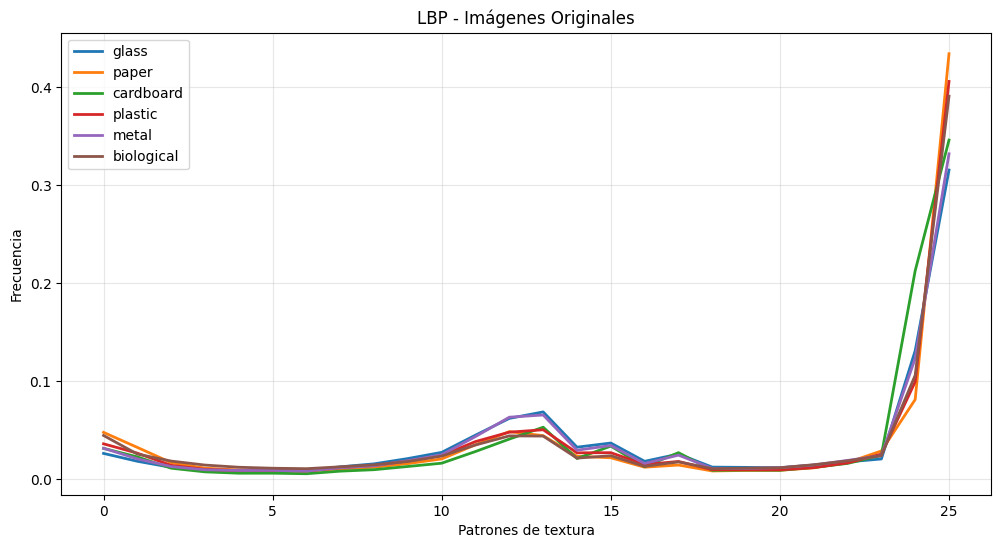

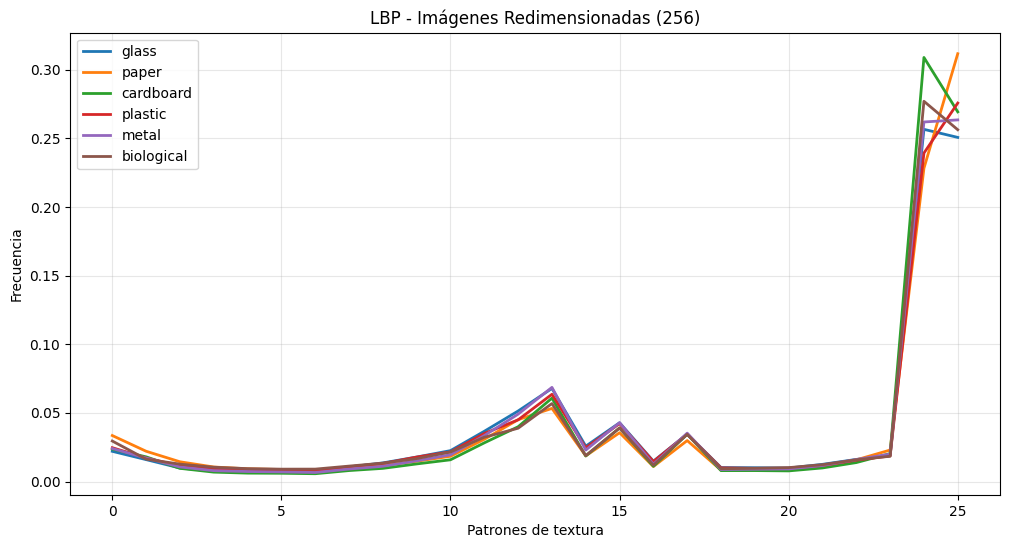

In [12]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from skimage.feature import local_binary_pattern

LBP_POINTS = 24
LBP_RADIUS = 3

def analizar_textura_global(directorio, categorias, titulo):
    plt.figure(figsize=(12, 6))
    
    for cat in categorias:
        ruta_cat = os.path.join(directorio, cat)
        archivos = [f for f in os.listdir(ruta_cat) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        
        random.shuffle(archivos)
        todos_los_lbp = []

        for nombre_f in archivos[:100]:
            img = cv2.imread(os.path.join(ruta_cat, nombre_f), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            img = cv2.resize(img, (128, 128))
            lbp = local_binary_pattern(img, LBP_POINTS, LBP_RADIUS, method='uniform')
            
            hist, _ = np.histogram(
                lbp.ravel(),
                bins=np.arange(0, LBP_POINTS + 3),
                density=True
            )
            todos_los_lbp.append(hist)
        
        if len(todos_los_lbp) > 0:
            promedio = np.mean(todos_los_lbp, axis=0)
            plt.plot(promedio, label=cat, linewidth=2)

    plt.title(titulo)
    plt.xlabel("Patrones de textura")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

analizar_textura_global(data_original, categorias_validas, "LBP - Imágenes Originales")
analizar_textura_global(data_256, categorias_validas, "LBP - Imágenes Redimensionadas (256)")

### Correlación de características visuales entre categorías

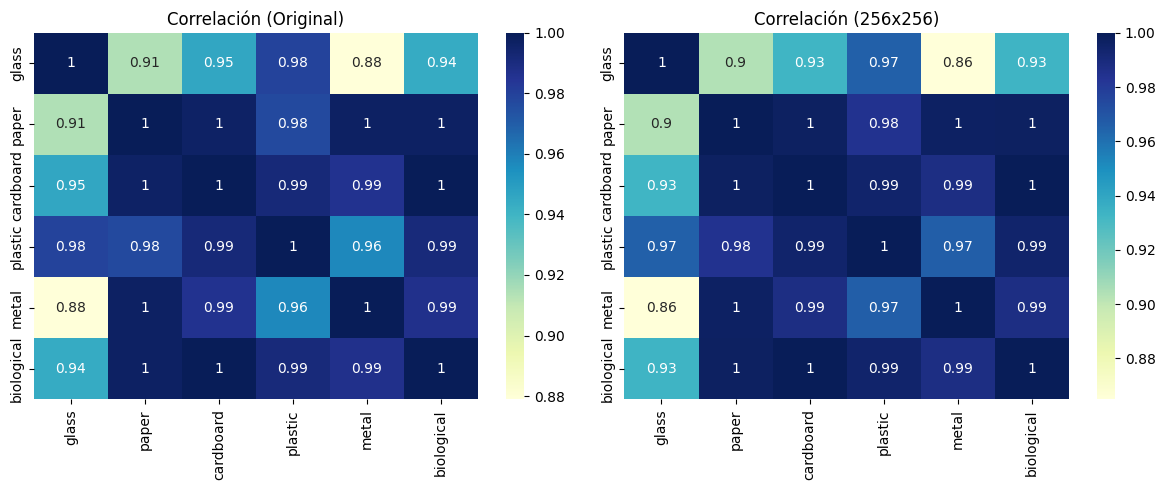

In [13]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

categorias = categorias_validas  

def matriz_color(data_dir, titulo):
    promedios_color = []

    for cat in categorias:
        ruta = os.path.join(data_dir, cat)
        fotos = [f for f in os.listdir(ruta) if f.lower().endswith(('.jpg', '.png', '.jpeg'))][:150]

        colores_cat = []

        for f in fotos:
            img = cv2.imread(os.path.join(ruta, f))
            if img is not None:
                colores_cat.append(np.mean(img, axis=(0,1))) 
        promedios_color.append(np.mean(colores_cat, axis=0))
    matriz_corr = np.corrcoef(promedios_color)
    return matriz_corr

matriz_original = matriz_color(data_original, "Original")
matriz_256 = matriz_color(data_256, "256x256")

plt.figure(figsize=(12,5))

# Original
plt.subplot(1,2,1)
sns.heatmap(matriz_original, annot=True, xticklabels=categorias, yticklabels=categorias, cmap='YlGnBu')
plt.title("Correlación (Original)")

# 256
plt.subplot(1,2,2)
sns.heatmap(matriz_256, annot=True, xticklabels=categorias, yticklabels=categorias, cmap='YlGnBu')
plt.title("Correlación (256x256)")

plt.tight_layout()
plt.show()

La matriz de correlación muestra la relación entre los patrones de color promedio de cada categoría.

Se identifican similitudes entre algunas clases, lo que podría representar un reto para el modelo.

Sin embargo, también se evidencian diferencias que pueden facilitar la clasificación automática.

### Correlación entre canales de color (RGB)

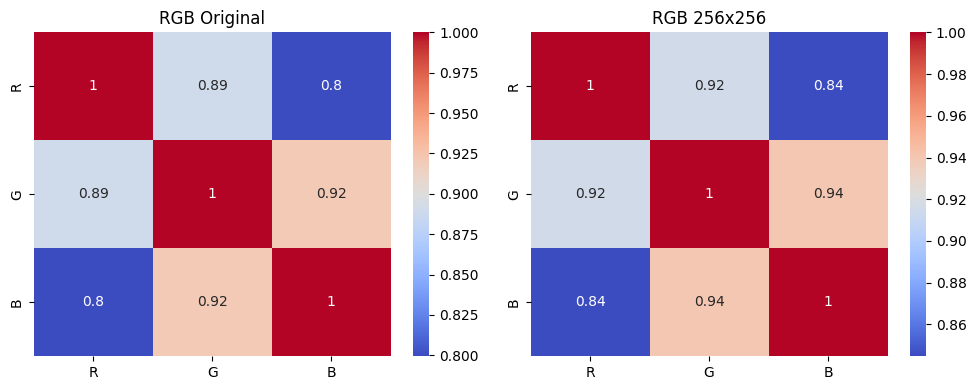

In [14]:
def correlacion_rgb(data_dir, titulo):
    canales = {'R': [], 'G': [], 'B': []}

    for cat in categorias_validas:
        ruta = os.path.join(data_dir, cat)
        imgs = os.listdir(ruta)[:50]

        for nombre in imgs:
            img = Image.open(os.path.join(ruta, nombre)).resize((256,256))
            arr = np.array(img)

            if len(arr.shape) == 3:
                canales['R'].append(np.mean(arr[:,:,0]))
                canales['G'].append(np.mean(arr[:,:,1]))
                canales['B'].append(np.mean(arr[:,:,2]))
    df = pd.DataFrame(canales)
    return df.corr()

corr_original = correlacion_rgb(data_original, "Original")
corr_256 = correlacion_rgb(data_256, "256x256")

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.heatmap(corr_original, annot=True, cmap='coolwarm')
plt.title("RGB Original")
plt.subplot(1,2,2)
sns.heatmap(corr_256, annot=True, cmap='coolwarm')
plt.title("RGB 256x256")
plt.tight_layout()
plt.show()

## Promedio de color por categoría

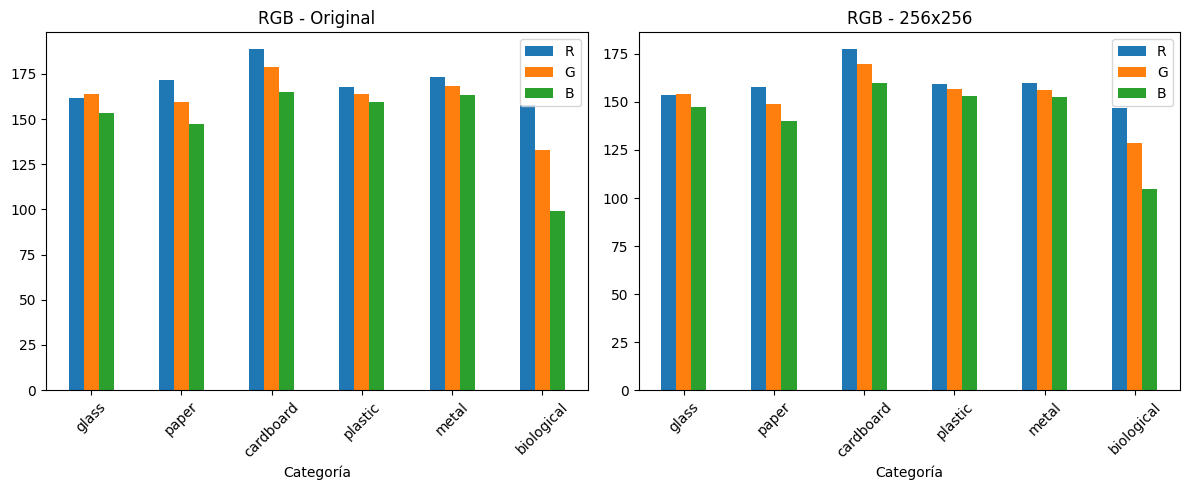

In [15]:
def promedio_rgb(data_dir):
    datos = []

    for cat in categorias_validas:
        ruta = os.path.join(data_dir, cat)
        imgs = os.listdir(ruta)[:30]
        r, g, b = [], [], []

        for nombre in imgs:
            img = Image.open(os.path.join(ruta, nombre)).resize((256,256))
            arr = np.array(img)
            if len(arr.shape) == 3:
                r.append(np.mean(arr[:,:,0]))
                g.append(np.mean(arr[:,:,1]))
                b.append(np.mean(arr[:,:,2]))
        datos.append({
            "Categoría": cat,
            "R": np.mean(r),
            "G": np.mean(g),
            "B": np.mean(b)
        })
    return pd.DataFrame(datos)

df_original = promedio_rgb(data_original)
df_256 = promedio_rgb(data_256)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
df_original.set_index("Categoría").plot(kind="bar", ax=plt.gca())
plt.title("RGB - Original")
plt.xticks(rotation=45)
plt.subplot(1,2,2)
df_256.set_index("Categoría").plot(kind="bar", ax=plt.gca())
plt.title("RGB - 256x256")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Calidad de los datos

Se verificó la existencia de imágenes en todas las categorías tanto en el dataset original como en el estandarizado.

No se encontraron carpetas vacías ni errores estructurales.

Se evidencia un desbalance entre clases, lo cual puede afectar el desempeño del modelo.

La versión estandarizada corrige diferencias de tamaño, facilitando el procesamiento.

## Análisis de patrones

El análisis de los canales RGB muestra correlaciones entre los colores presentes en las imágenes.

Se identifican diferencias de color entre categorías, lo cual puede ser útil para el modelo.

El dataset presenta características visuales distinguibles que pueden ser aprovechadas por técnicas de Deep Learning.

# Segunda entrega proyecto

In [16]:
#Importación de librerías
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random
import warnings
warnings.filterwarnings('ignore')
 
from PIL import Image
from skimage.feature import hog, local_binary_pattern
from scipy.stats import skew, kurtosis
 
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    mean_squared_error, r2_score
)
 
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [17]:
#Rutas y categorías
data_256 = "/kaggle/input/datasets/sumn2u/garbage-classification-v2/standardized_256"
 
categorias_validas = ["glass", "paper", "cardboard", "plastic", "metal", "biological"]
 
# Verificar que existen las carpetas
for cat in categorias_validas:
    ruta = os.path.join(data_256, cat)
    n = len(os.listdir(ruta))
    print(f"  {cat}: {n} imágenes")

  glass: 1736 imágenes
  paper: 1336 imágenes
  cardboard: 1411 imágenes
  plastic: 1597 imágenes
  metal: 930 imágenes
  biological: 699 imágenes


## Análisis exploratorio de datos (EDA)
Este EDA analiza las variables numéricas derivadas de las imágenes del dataset de clasificación de residuos. Se analizan estadísticas de brillo, contraste, saturación e histogramas de color por categoría.

In [18]:
print("Calculando estadísticas por categoría...")
 
stats_data = []
for cat in categorias_validas:
    ruta = os.path.join(data_256, cat)
    archivos = [f for f in os.listdir(ruta) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    muestra = random.sample(archivos, min(100, len(archivos)))
 
    brillos, contrastes, saturaciones, nitideces = [], [], [], []
 
    for nombre in muestra:
        img = cv2.imread(os.path.join(ruta, nombre))
        if img is None:
            continue
 
        # Brillo: promedio del canal V en HSV
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        brillo = np.mean(hsv[:, :, 2])
        saturacion = np.mean(hsv[:, :, 1])
        brillos.append(brillo)
        saturaciones.append(saturacion)
 
        # Contraste: desviación estándar de escala de grises
        gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        contrastes.append(np.std(gris))
 
        # Nitidez: varianza del Laplaciano
        laplacian = cv2.Laplacian(gris, cv2.CV_64F)
        nitideces.append(laplacian.var())
 
    stats_data.append({
        'Categoría': cat,
        'Brillo_Media': np.mean(brillos),
        'Brillo_Std': np.std(brillos),
        'Contraste_Media': np.mean(contrastes),
        'Contraste_Std': np.std(contrastes),
        'Saturacion_Media': np.mean(saturaciones),
        'Saturacion_Std': np.std(saturaciones),
        'Nitidez_Media': np.mean(nitideces),
        'Nitidez_Std': np.std(nitideces),
        'Sesgo_Brillo': skew(brillos),
        'Curtosis_Brillo': kurtosis(brillos),
    })
 
df_stats = pd.DataFrame(stats_data)
print(df_stats[['Categoría', 'Brillo_Media', 'Contraste_Media', 'Saturacion_Media', 'Nitidez_Media']].round(2))

Calculando estadísticas por categoría...
    Categoría  Brillo_Media  Contraste_Media  Saturacion_Media  Nitidez_Media
0       glass        172.18            52.17             44.78         613.03
1       paper        151.04            47.68             37.06        1504.98
2   cardboard        185.15            50.90             46.33        1205.53
3     plastic        155.20            43.87             31.66         659.68
4       metal        156.01            52.98             33.60        1072.62
5  biological        147.57            49.79             76.17         972.87


### Visualizaciones EDA

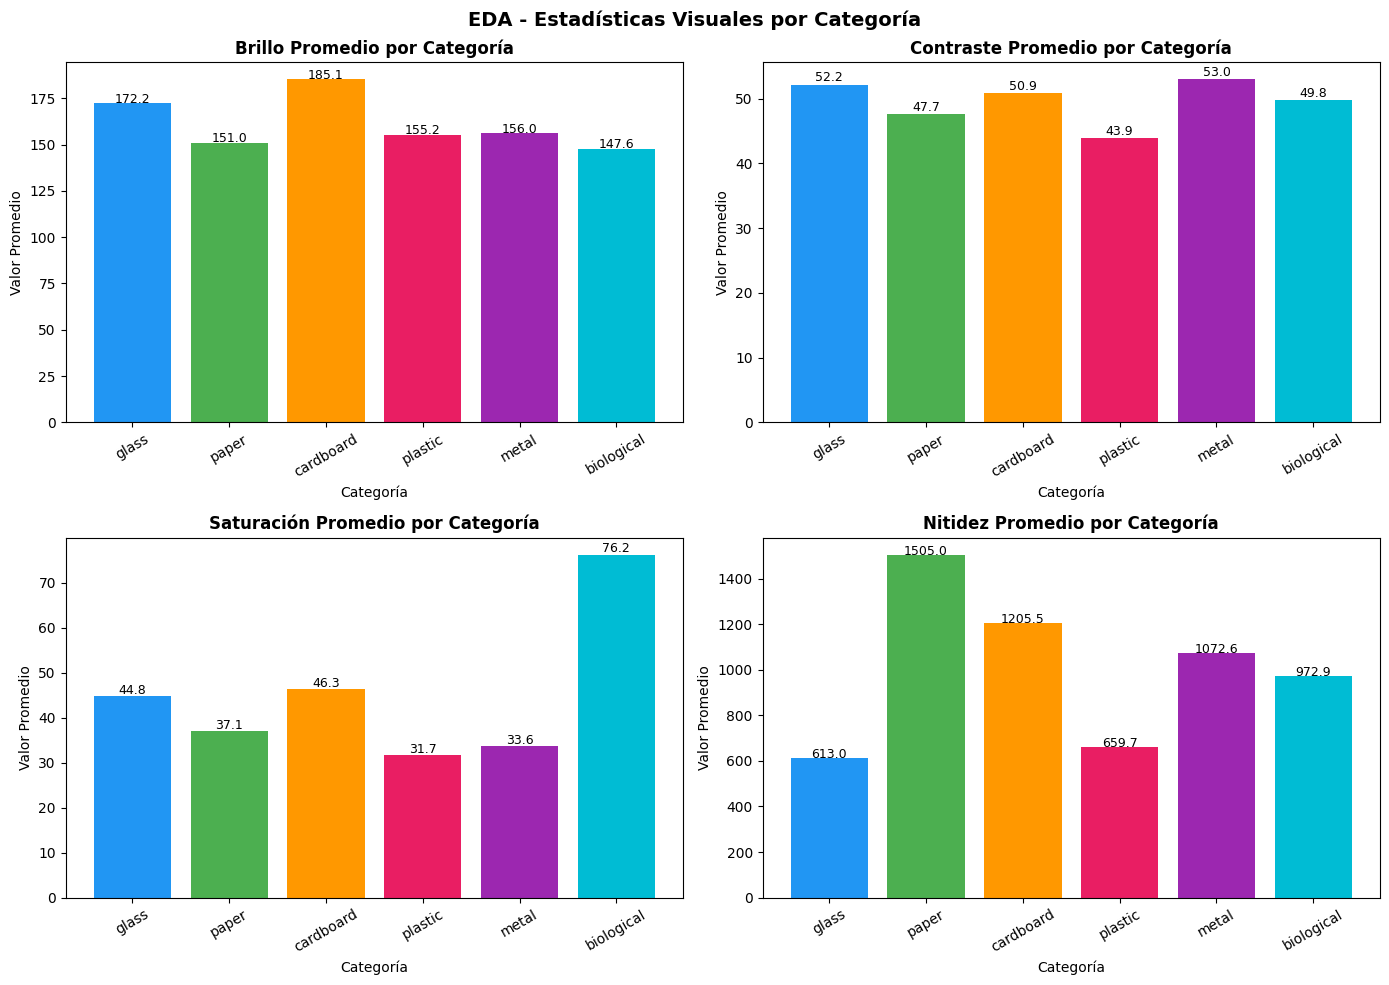

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
 
metricas = ['Brillo_Media', 'Contraste_Media', 'Saturacion_Media', 'Nitidez_Media']
titulos = ['Brillo Promedio por Categoría', 'Contraste Promedio por Categoría',
           'Saturación Promedio por Categoría', 'Nitidez Promedio por Categoría']
 
colores = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4']
 
for ax, metrica, titulo in zip(axes.flatten(), metricas, titulos):
    ax.bar(df_stats['Categoría'], df_stats[metrica], color=colores)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Categoría')
    ax.set_ylabel('Valor Promedio')
    ax.tick_params(axis='x', rotation=30)
    for i, v in enumerate(df_stats[metrica]):
        ax.text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=9)
 
plt.suptitle('EDA - Estadísticas Visuales por Categoría', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Distribución de variables numéricas (Histogramas y Boxplots)

Recolectando datos por imagen para distribuciones...


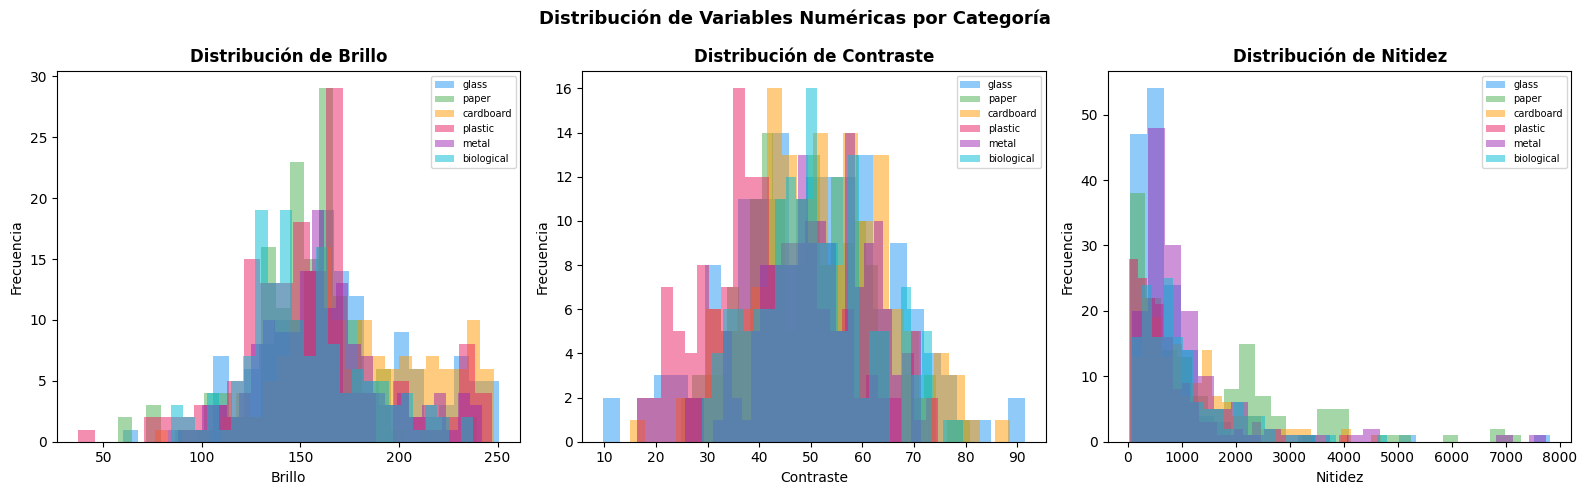

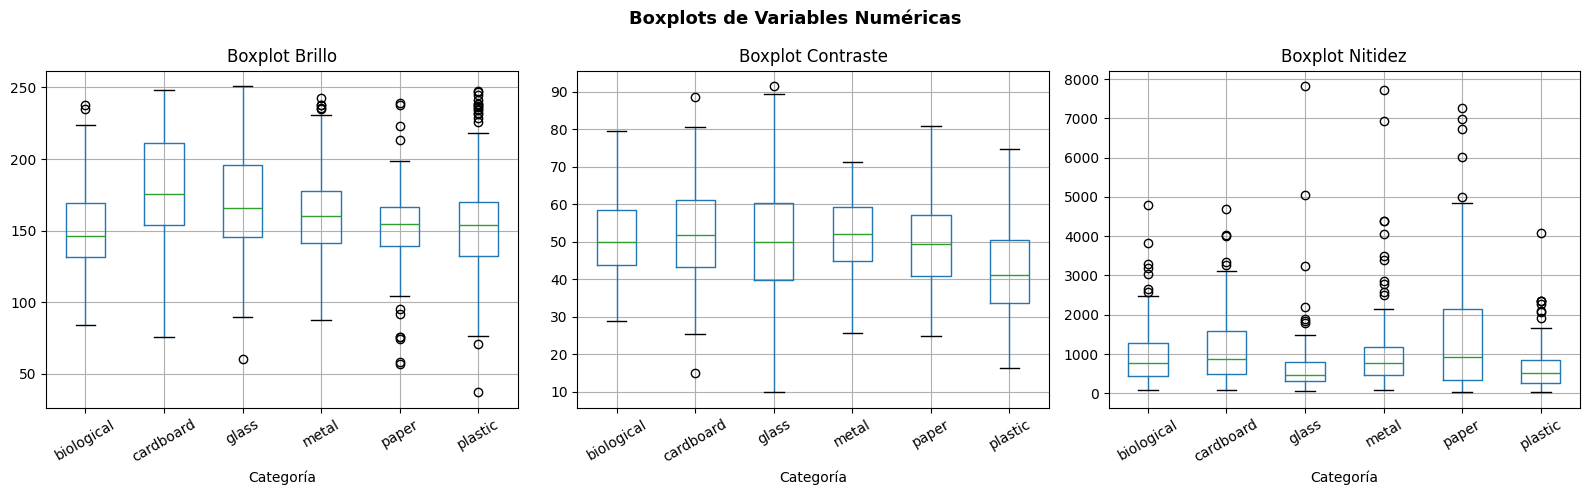

In [20]:
print("Recolectando datos por imagen para distribuciones...")
 
datos_por_imagen = []
for cat in categorias_validas:
    ruta = os.path.join(data_256, cat)
    archivos = [f for f in os.listdir(ruta) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    muestra = random.sample(archivos, min(150, len(archivos)))
 
    for nombre in muestra:
        img = cv2.imread(os.path.join(ruta, nombre))
        if img is None:
            continue
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        brillo = np.mean(hsv[:, :, 2])
        contraste = np.std(gris)
        lap = cv2.Laplacian(gris, cv2.CV_64F)
        nitidez = lap.var()
 
        datos_por_imagen.append({
            'Categoría': cat, 'Brillo': brillo,
            'Contraste': contraste, 'Nitidez': nitidez
        })
 
df_img = pd.DataFrame(datos_por_imagen)
 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, titulo in zip(axes, ['Brillo', 'Contraste', 'Nitidez'],
                           ['Distribución de Brillo', 'Distribución de Contraste', 'Distribución de Nitidez']):
    for cat, color in zip(categorias_validas, colores):
        vals = df_img[df_img['Categoría'] == cat][col]
        ax.hist(vals, bins=25, alpha=0.5, label=cat, color=color)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=7)
 
plt.suptitle('Distribución de Variables Numéricas por Categoría', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
 
# Boxplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ['Brillo', 'Contraste', 'Nitidez']):
    df_img.boxplot(column=col, by='Categoría', ax=ax)
    ax.set_title(f'Boxplot {col}')
    ax.set_xlabel('Categoría')
    ax.tick_params(axis='x', rotation=30)
 
plt.suptitle('Boxplots de Variables Numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Reporte EDA - Descripción estadística por variable

In [21]:
print("\n=== ESTADÍSTICAS DESCRIPTIVAS COMPLETAS ===")
for col in ['Brillo', 'Contraste', 'Nitidez']:
    print(f"\n--- {col} ---")
    for cat in categorias_validas:
        vals = df_img[df_img['Categoría'] == cat][col]
        sesgo = skew(vals)
        tipo = "Simétrica (normal)" if abs(sesgo) < 0.5 else ("Sesgada derecha" if sesgo > 0 else "Sesgada izquierda")
        if abs(sesgo) < 0.5:
            print(f"  {cat}: Media={vals.mean():.2f} ± {vals.std():.2f} | Distribución: {tipo}")
        else:
            print(f"  {cat}: Mediana={vals.median():.2f} | IQR=[{vals.quantile(0.25):.2f}, {vals.quantile(0.75):.2f}] | Distribución: {tipo}")


=== ESTADÍSTICAS DESCRIPTIVAS COMPLETAS ===

--- Brillo ---
  glass: Media=170.04 ± 37.78 | Distribución: Simétrica (normal)
  paper: Media=152.47 ± 28.64 | Distribución: Simétrica (normal)
  cardboard: Media=180.35 ± 37.17 | Distribución: Simétrica (normal)
  plastic: Media=156.41 ± 38.00 | Distribución: Simétrica (normal)
  metal: Media=162.39 ± 32.13 | Distribución: Simétrica (normal)
  biological: Media=152.16 ± 30.61 | Distribución: Simétrica (normal)

--- Contraste ---
  glass: Media=50.16 ± 15.46 | Distribución: Simétrica (normal)
  paper: Media=49.34 ± 11.25 | Distribución: Simétrica (normal)
  cardboard: Media=52.24 ± 12.99 | Distribución: Simétrica (normal)
  plastic: Media=42.10 ± 12.70 | Distribución: Simétrica (normal)
  metal: Media=51.54 ± 9.92 | Distribución: Simétrica (normal)
  biological: Media=50.90 ± 11.01 | Distribución: Simétrica (normal)

--- Nitidez ---
  glass: Mediana=476.74 | IQR=[304.61, 794.61] | Distribución: Sesgada derecha
  paper: Mediana=933.08 | IQR

## Preprocesamiento de Datos
1. **Manejo de valores nulos:** Las imágenes que no se puedan leer (img is None) son descartadas del dataset.
2. **Valores atípicos (Outliers):** Para la extracción de características, los valores extremos de nitidez
(imágenes completamente borrosas o sobreexpuestas) se filtran usando IQR.
3. **Extracción de características y normalización:** Se extraen características HOG y estadísticas de color. Los vectores de características se normalizan usando StandardScaler para asegurar que todos los modelos reciban datos en la misma escala.

In [22]:
print("Extrayendo características HOG + Color de las imágenes...")
print("Esto puede tardar unos minutos...")
 
def extraer_caracteristicas(ruta_img):
    """Extrae características HOG + histograma de color de una imagen."""
    img = cv2.imread(ruta_img)
    if img is None:
        return None
 
    # Redimensionar a tamaño fijo para HOG
    img_resized = cv2.resize(img, (64, 64))
    gris = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
 
    # Características HOG (forma/textura)
    hog_features = hog(gris, orientations=9, pixels_per_cell=(8, 8),
                       cells_per_block=(2, 2), visualize=False)
 
    # Histograma de color por canal (18 features: 3 canales × 6 bins)
    hist_features = []
    for ch in range(3):
        hist = cv2.calcHist([img_resized], [ch], None, [6], [0, 256])
        hist_features.extend(hist.flatten() / hist.sum())
 
    # Estadísticas de color (6 features)
    hsv = cv2.cvtColor(img_resized, cv2.COLOR_BGR2HSV)
    stats = [
        np.mean(hsv[:, :, 0]),  # Tono medio
        np.std(hsv[:, :, 0]),   # Variación de tono
        np.mean(hsv[:, :, 1]),  # Saturación media
        np.mean(hsv[:, :, 2]),  # Brillo medio
        np.std(gris),           # Contraste
        cv2.Laplacian(gris, cv2.CV_64F).var()  # Nitidez
    ]
 
    return np.concatenate([hog_features, hist_features, stats])
 
# Extraer características de TODAS las imágenes
X_raw, y_raw = [], []
imagenes_omitidas = 0
 
for cat in categorias_validas:
    ruta = os.path.join(data_256, cat)
    archivos = [f for f in os.listdir(ruta) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    print(f"  Procesando {cat}: {len(archivos)} imágenes...")
 
    for nombre in archivos:
        feats = extraer_caracteristicas(os.path.join(ruta, nombre))
        if feats is not None:
            X_raw.append(feats)
            y_raw.append(cat)
        else:
            imagenes_omitidas += 1
 
X_raw = np.array(X_raw)
y_raw = np.array(y_raw)
 
print(f"\n Total imágenes procesadas: {len(X_raw)}")
print(f"   Imágenes omitidas (nulas): {imagenes_omitidas}")
print(f"   Dimensión del vector de características: {X_raw.shape[1]}")
print(f"   Clases: {np.unique(y_raw)}")

Extrayendo características HOG + Color de las imágenes...
Esto puede tardar unos minutos...
  Procesando glass: 1736 imágenes...
  Procesando paper: 1336 imágenes...
  Procesando cardboard: 1411 imágenes...
  Procesando plastic: 1597 imágenes...
  Procesando metal: 930 imágenes...
  Procesando biological: 699 imágenes...

 Total imágenes procesadas: 7709
   Imágenes omitidas (nulas): 0
   Dimensión del vector de características: 1788
   Clases: ['biological' 'cardboard' 'glass' 'metal' 'paper' 'plastic']


## Tratamiento de Outliers y Normalización

In [23]:
print("\n=== Tratamiento de outliers por IQR ===")
 
# Filtrar outliers usando la última característica (nitidez) como proxy
nitidez_col = X_raw[:, -1]  # Última columna: nitidez
Q1, Q3 = np.percentile(nitidez_col, 25), np.percentile(nitidez_col, 75)
IQR = Q3 - Q1
lower, upper = Q1 - 3 * IQR, Q3 + 3 * IQR
 
mask = (nitidez_col >= lower) & (nitidez_col <= upper)
n_antes = len(X_raw)
X_raw = X_raw[mask]
y_raw = y_raw[mask]
n_despues = len(X_raw)
print(f"  Imágenes antes del filtro: {n_antes}")
print(f"  Imágenes eliminadas (outliers extremos de nitidez): {n_antes - n_despues}")
print(f"  Imágenes después del filtro: {n_despues}")
 
# Codificación de etiquetas
le = LabelEncoder()
y = le.fit_transform(y_raw)
print(f"\n  Clases codificadas: {dict(zip(le.classes_, le.transform(le.classes_)))}")
 
# División train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n  Train: {X_train.shape[0]} imágenes")
print(f"  Test:  {X_test.shape[0]} imágenes")
 
# Normalización con StandardScaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
print("\n Datos normalizados con StandardScaler.")


=== Tratamiento de outliers por IQR ===
  Imágenes antes del filtro: 7709
  Imágenes eliminadas (outliers extremos de nitidez): 94
  Imágenes después del filtro: 7615

  Clases codificadas: {np.str_('biological'): np.int64(0), np.str_('cardboard'): np.int64(1), np.str_('glass'): np.int64(2), np.str_('metal'): np.int64(3), np.str_('paper'): np.int64(4), np.str_('plastic'): np.int64(5)}

  Train: 6092 imágenes
  Test:  1523 imágenes

 Datos normalizados con StandardScaler.


## Selección de Características (Feature Selection) — SelectKBest

A diferencia de PCA (que crea componentes nuevas), aquí aplicamos un método
formal de selección que conserva las características ORIGINALES más
discriminativas usando la prueba estadística ANOVA F (f_classif).
Esto reduce ruido y mejora la interpretabilidad del modelo.

In [24]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier

print("="*60)
print("SELECCIÓN DE CARACTERÍSTICAS — SelectKBest (ANOVA F)")
print("="*60)

K_FEATURES = 50
selector = SelectKBest(score_func=f_classif, k=K_FEATURES)
X_train_sel = selector.fit_transform(X_train_sc, y_train)
X_test_sel  = selector.transform(X_test_sc)

print(f"Características originales: {X_train_sc.shape[1]}")
print(f"Características seleccionadas: {X_train_sel.shape[1]}")

rf_full = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_sc, y_train)
rf_sel  = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_sel, y_train)
acc_full = accuracy_score(y_test, rf_full.predict(X_test_sc))
acc_sel  = accuracy_score(y_test, rf_sel.predict(X_test_sel))

print(f"\nAccuracy con TODAS las características:      {acc_full:.4f}")
print(f"Accuracy con {K_FEATURES} características seleccionadas: {acc_sel:.4f}")
print(f"Diferencia: {(acc_sel-acc_full)*100:+.2f} puntos porcentuales")
print(f"\n→ Reducción del {(1-K_FEATURES/X_train_sc.shape[1])*100:.0f}% de features "
      f"manteniendo un rendimiento {'similar' if abs(acc_sel-acc_full)<0.03 else 'distinto'}.")

SELECCIÓN DE CARACTERÍSTICAS — SelectKBest (ANOVA F)
Características originales: 1788
Características seleccionadas: 50

Accuracy con TODAS las características:      0.6179
Accuracy con 50 características seleccionadas: 0.6402
Diferencia: +2.23 puntos porcentuales

→ Reducción del 97% de features manteniendo un rendimiento similar.


## Función auxiliar de métricas

In [25]:
def calcular_metricas(nombre_modelo, y_true, y_pred, clases):
    """Calcula accuracy, precision, recall, F1 y especificidad."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
 
    # Especificidad = TN / (TN + FP) → promedio macro
    cm = confusion_matrix(y_true, y_pred)
    especificidades = []
    for i in range(len(clases)):
        TN = np.delete(np.delete(cm, i, axis=0), i, axis=1).sum()
        FP = cm[:, i].sum() - cm[i, i]
        especificidades.append(TN / (TN + FP) if (TN + FP) > 0 else 0)
    especificidad = np.mean(especificidades)
 
    return {
        'Modelo': nombre_modelo,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'Especificidad': round(especificidad, 4)
    }
 
def mostrar_confusion_matrix(y_true, y_pred, clases, titulo):
    """Muestra la matriz de confusión."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=clases, yticklabels=clases)
    plt.title(titulo, fontweight='bold')
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.tight_layout()
    plt.show()
 
resultados_todos = []

## Modelo 1 - Gaussian Naive Bayes (GNB)
El GNB asume que las características siguen una distribución gaussiana dentro de cada clase. Es rápido y funciona bien como baseline.

**Limitación:** La asunción de independencia entre características puede no ser ideal para datos de imagen con alta correlación espacial.

MODELO 1: GAUSSIAN NAIVE BAYES
Modelo  Accuracy  Precision  Recall  F1-Score  Especificidad
   GNB    0.3959      0.466  0.3959    0.4018         0.8808


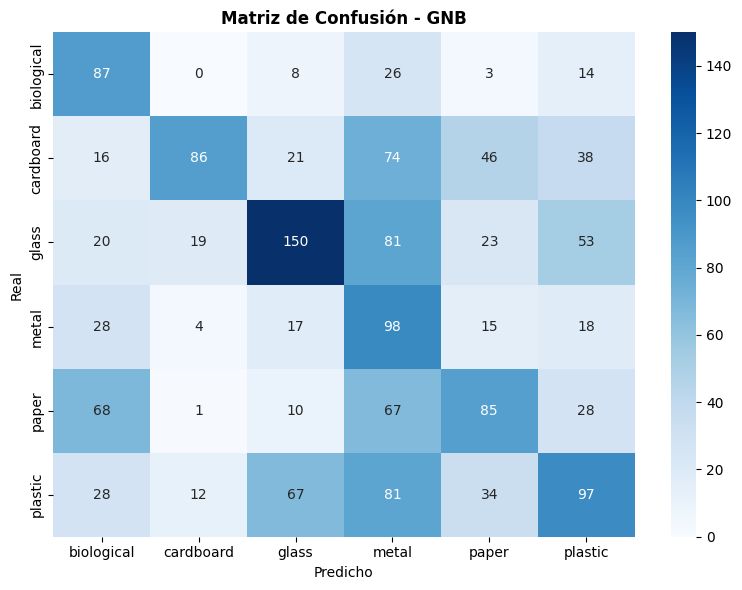

In [26]:
print("="*60)
print("MODELO 1: GAUSSIAN NAIVE BAYES")
print("="*60)
 
gnb = GaussianNB()
gnb.fit(X_train_sc, y_train)
y_pred_gnb = gnb.predict(X_test_sc)
 
metricas_gnb = calcular_metricas("GNB", y_test, y_pred_gnb, le.classes_)
f1_gnb = metricas_gnb["F1-Score"]
print(pd.DataFrame([metricas_gnb]).to_string(index=False))
 
mostrar_confusion_matrix(y_test, y_pred_gnb, le.classes_, "Matriz de Confusión - GNB")
 
resultados_todos.append(metricas_gnb)

## Ablation Study GNB - var_smoothing


--- Ablation Study: GNB - var_smoothing ---
 var_smoothing  Accuracy
  1.000000e-12  0.395929
  1.000000e-10  0.395929
  1.000000e-09  0.395929
  1.000000e-07  0.395929
  1.000000e-05  0.395929
  1.000000e-03  0.395929


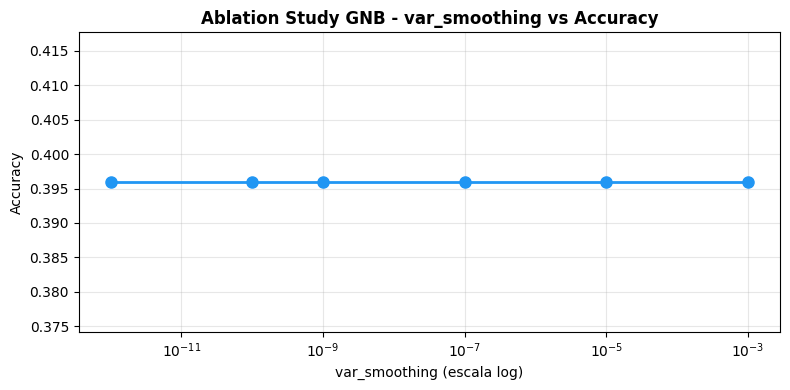

In [27]:
print("\n--- Ablation Study: GNB - var_smoothing ---")
var_smoothing_vals = [1e-12, 1e-10, 1e-9, 1e-7, 1e-5, 1e-3]
acc_gnb_ablation = []
 
for vs in var_smoothing_vals:
    m = GaussianNB(var_smoothing=vs)
    m.fit(X_train_sc, y_train)
    acc_gnb_ablation.append(accuracy_score(y_test, m.predict(X_test_sc)))
 
df_gnb_ablation = pd.DataFrame({'var_smoothing': var_smoothing_vals, 'Accuracy': acc_gnb_ablation})
print(df_gnb_ablation.to_string(index=False))
 
plt.figure(figsize=(8, 4))
plt.semilogx(var_smoothing_vals, acc_gnb_ablation, 'o-', color='#2196F3', linewidth=2, markersize=8)
plt.title('Ablation Study GNB - var_smoothing vs Accuracy', fontweight='bold')
plt.xlabel('var_smoothing (escala log)')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Modelo 2 - Árbol de decisión (DT)
El árbol de decisión crea reglas jerárquicas de clasificación. Es interpretable, pero tiende a sobreajustarse con profundidades grandes. Se limita la profundidad (max_depth) para mejorar la generalización.


MODELO 2: ÁRBOL DE DECISIÓN
Modelo  Accuracy  Precision  Recall  F1-Score  Especificidad
    DT    0.4576     0.4618  0.4576    0.4593         0.8898


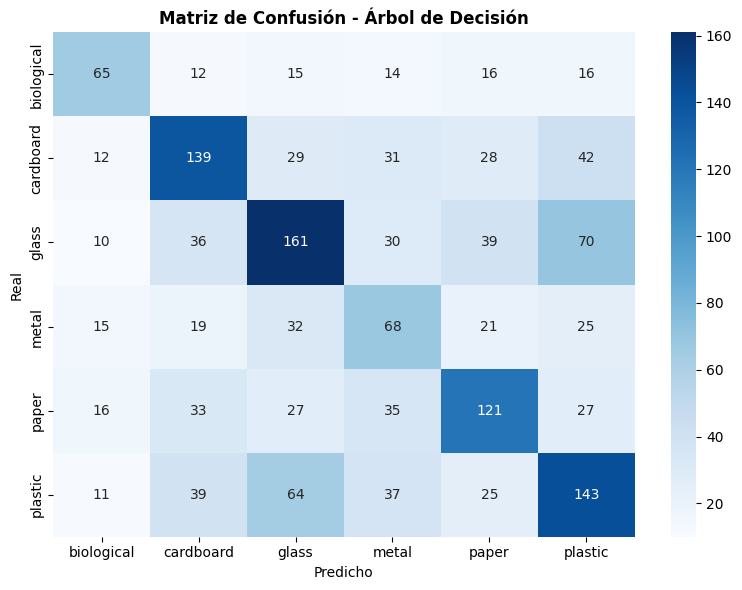

In [28]:
print("\n" + "="*60)
print("MODELO 2: ÁRBOL DE DECISIÓN")
print("="*60)
 
dt = DecisionTreeClassifier(max_depth=15, random_state=42)
dt.fit(X_train_sc, y_train)
y_pred_dt = dt.predict(X_test_sc)
 
metricas_dt = calcular_metricas("DT", y_test, y_pred_dt, le.classes_)
f1_dt  = metricas_dt["F1-Score"]
print(pd.DataFrame([metricas_dt]).to_string(index=False))
 
mostrar_confusion_matrix(y_test, y_pred_dt, le.classes_, "Matriz de Confusión - Árbol de Decisión")
 
resultados_todos.append(metricas_dt)

## Ablation Study DT - max_depth


--- Ablation Study: DT - max_depth ---
max_depth  Train Accuracy  Test Accuracy
        2        0.327315       0.323047
        5        0.495896       0.451740
        8        0.649540       0.503611
       10        0.779219       0.485227
       12        0.894780       0.467498
       15        0.976691       0.457649
       20        0.997209       0.448457
     None        1.000000       0.460276


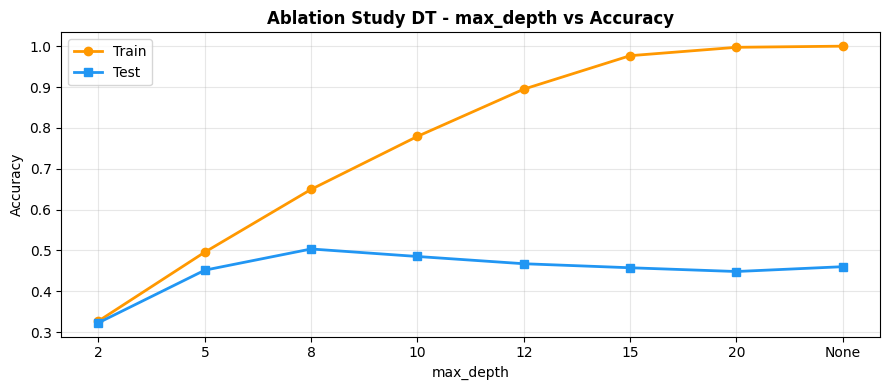

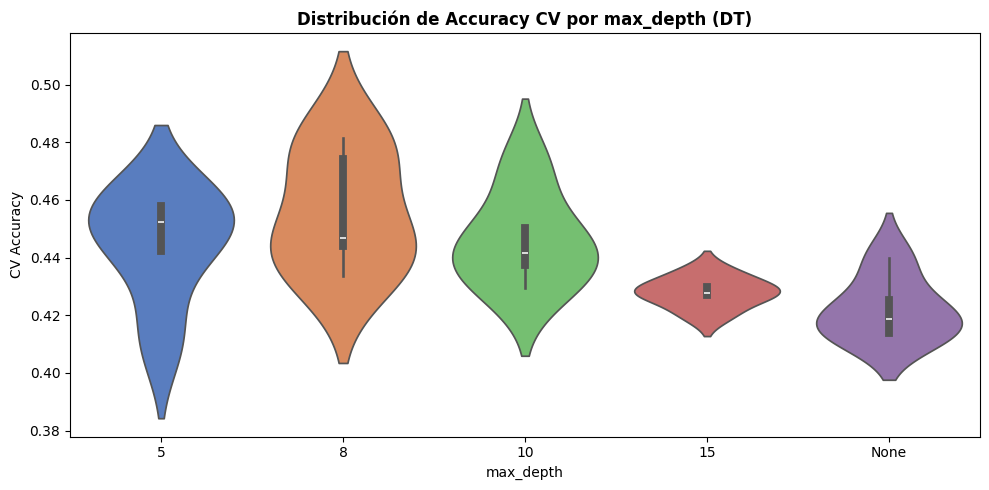

In [29]:
print("\n--- Ablation Study: DT - max_depth ---")
depths = [2, 5, 8, 10, 12, 15, 20, None]
acc_dt_train, acc_dt_test = [], []
 
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train_sc, y_train)
    acc_dt_train.append(accuracy_score(y_train, m.predict(X_train_sc)))
    acc_dt_test.append(accuracy_score(y_test, m.predict(X_test_sc)))
 
labels = [str(d) for d in depths]
df_dt_ablation = pd.DataFrame({'max_depth': labels, 'Train Accuracy': acc_dt_train, 'Test Accuracy': acc_dt_test})
print(df_dt_ablation.to_string(index=False))
 
plt.figure(figsize=(9, 4))
plt.plot(labels, acc_dt_train, 'o-', label='Train', color='#FF9800', linewidth=2)
plt.plot(labels, acc_dt_test, 's-', label='Test', color='#2196F3', linewidth=2)
plt.title('Ablation Study DT - max_depth vs Accuracy', fontweight='bold')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
 
# Violin plot
plt.figure(figsize=(10, 5))
cv_scores = []
depth_labels = []
for d in [5, 8, 10, 15, None]:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    scores = cross_val_score(m, X_train_sc, y_train, cv=5, scoring='accuracy')
    cv_scores.extend(scores)
    depth_labels.extend([str(d)]*5)
 
df_vio = pd.DataFrame({'max_depth': depth_labels, 'CV Accuracy': cv_scores})
sns.violinplot(data=df_vio, x='max_depth', y='CV Accuracy', palette='muted')
plt.title('Distribución de Accuracy CV por max_depth (DT)', fontweight='bold')
plt.tight_layout()
plt.show()

## Modelo 3 - Random Forest (RF)
El Random Forest ensambla múltiples árboles de decisión entrenados
en subconjuntos aleatorios de datos y características. Reduce el sobreajuste del árbol individual y mejora la generalización. Es el modelo más robusto para datos de alta dimensionalidad.


MODELO 3: RANDOM FOREST
       Modelo  Accuracy  Precision  Recall  F1-Score  Especificidad
Random Forest     0.608     0.6114   0.608     0.605         0.9197


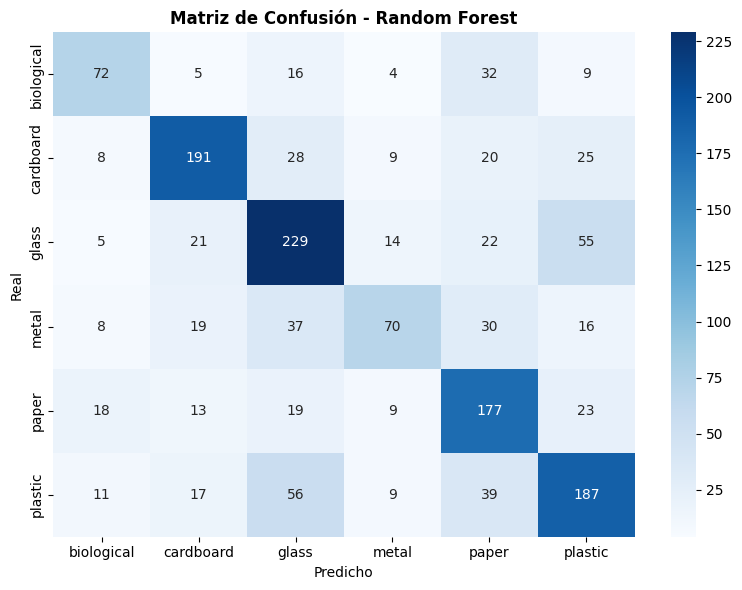

In [30]:
print("\n" + "="*60)
print("MODELO 3: RANDOM FOREST")
print("="*60)
 
rf = RandomForestClassifier(n_estimators=150, max_depth=20,
                            random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)
 
metricas_rf = calcular_metricas("Random Forest", y_test, y_pred_rf, le.classes_)
f1_rf  = metricas_rf["F1-Score"]
print(pd.DataFrame([metricas_rf]).to_string(index=False))
 
mostrar_confusion_matrix(y_test, y_pred_rf, le.classes_, "Matriz de Confusión - Random Forest")
 
resultados_todos.append(metricas_rf)

## Ablation Study RF - n_estimators


--- Ablation Study: RF - n_estimators ---
 n_estimators  Accuracy
           10  0.490479
           25  0.561392
           50  0.588969
           75  0.597505
          100  0.602101
          150  0.608011
          200  0.610637


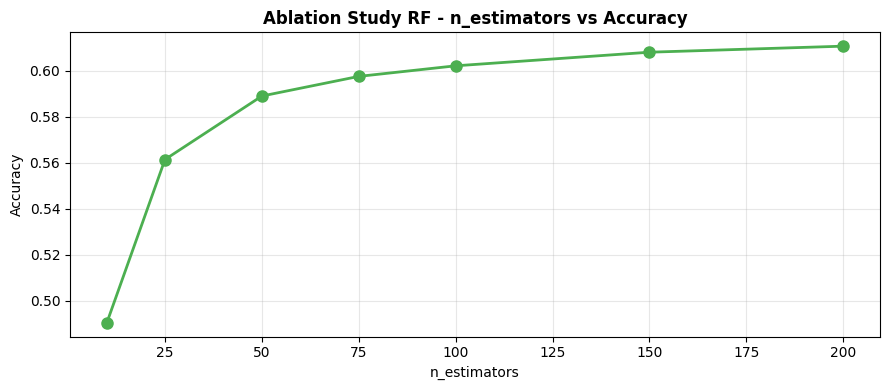

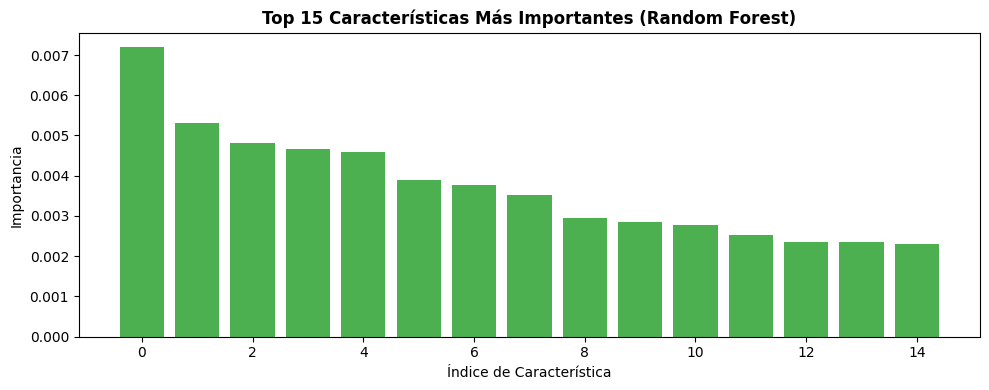

In [31]:
print("\n--- Ablation Study: RF - n_estimators ---")
n_estimadores = [10, 25, 50, 75, 100, 150, 200]
acc_rf_ablation = []
 
for n in n_estimadores:
    m = RandomForestClassifier(n_estimators=n, max_depth=20, random_state=42, n_jobs=-1)
    m.fit(X_train_sc, y_train)
    acc_rf_ablation.append(accuracy_score(y_test, m.predict(X_test_sc)))
 
df_rf_ablation = pd.DataFrame({'n_estimators': n_estimadores, 'Accuracy': acc_rf_ablation})
print(df_rf_ablation.to_string(index=False))
 
plt.figure(figsize=(9, 4))
plt.plot(n_estimadores, acc_rf_ablation, 'o-', color='#4CAF50', linewidth=2, markersize=8)
plt.title('Ablation Study RF - n_estimators vs Accuracy', fontweight='bold')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
 
# Importancia de características
feat_importance = rf.feature_importances_
top_idx = np.argsort(feat_importance)[-15:][::-1]
 
plt.figure(figsize=(10, 4))
plt.bar(range(15), feat_importance[top_idx], color='#4CAF50')
plt.title('Top 15 Características Más Importantes (Random Forest)', fontweight='bold')
plt.xlabel('Índice de Característica')
plt.ylabel('Importancia')
plt.tight_layout()
plt.show()

## Modelo 4 - SVM
El SVM busca el hiperplano de máximo margen que separa las clases. Con el kernel RBF, puede capturar relaciones no lineales. El parámetro C controla el trade-off entre margen y error de clasificación. 

**Nota:** Para datasets grandes, se trabaja con un subconjunto para eficiencia.


MODELO 4: SVM
  (Usando subconjunto de 3000 muestras para SVM)
Modelo  Accuracy  Precision  Recall  F1-Score  Especificidad
   SVM    0.6028     0.5991  0.6028    0.5989          0.919


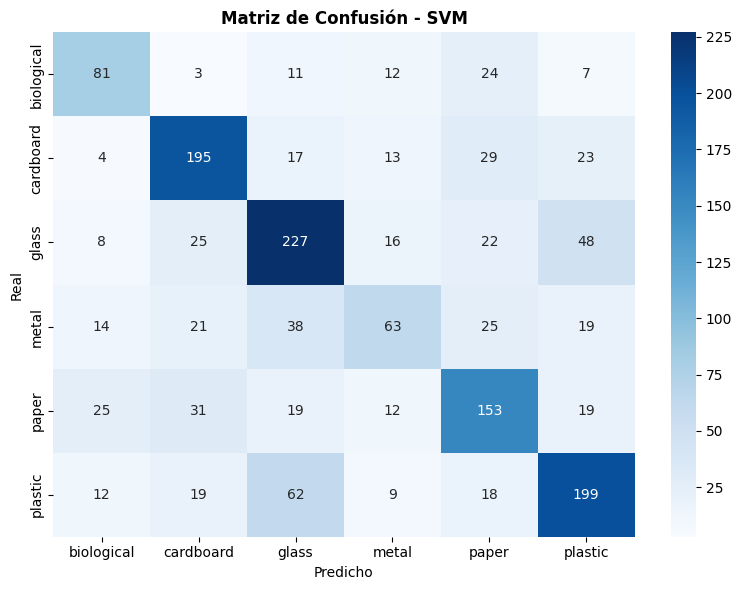

In [32]:
print("\n" + "="*60)
print("MODELO 4: SVM")
print("="*60)
 
# Usar subconjunto para eficiencia computacional si el dataset es grande
MAX_TRAIN = 3000
if X_train_sc.shape[0] > MAX_TRAIN:
    idx = np.random.choice(X_train_sc.shape[0], MAX_TRAIN, replace=False)
    X_tr_svm, y_tr_svm = X_train_sc[idx], y_train[idx]
    print(f"  (Usando subconjunto de {MAX_TRAIN} muestras para SVM)")
else:
    X_tr_svm, y_tr_svm = X_train_sc, y_train
 
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(X_tr_svm, y_tr_svm)
y_pred_svm = svm.predict(X_test_sc)
 
metricas_svm = calcular_metricas("SVM", y_test, y_pred_svm, le.classes_)
f1_svm = metricas_svm["F1-Score"]
print(pd.DataFrame([metricas_svm]).to_string(index=False))
 
mostrar_confusion_matrix(y_test, y_pred_svm, le.classes_, "Matriz de Confusión - SVM")
 
resultados_todos.append(metricas_svm)

## Ablation Study SVM - C y Kernel


--- Ablation Study: SVM - parámetro C ---
    C  Accuracy
  0.1  0.405121
  1.0  0.585686
  5.0  0.602758
 10.0  0.602758
 50.0  0.602758
100.0  0.602758

--- Ablation Study: SVM - kernel ---
 Kernel  Accuracy
 linear  0.499015
    rbf  0.602758
   poly  0.590282
sigmoid  0.463559


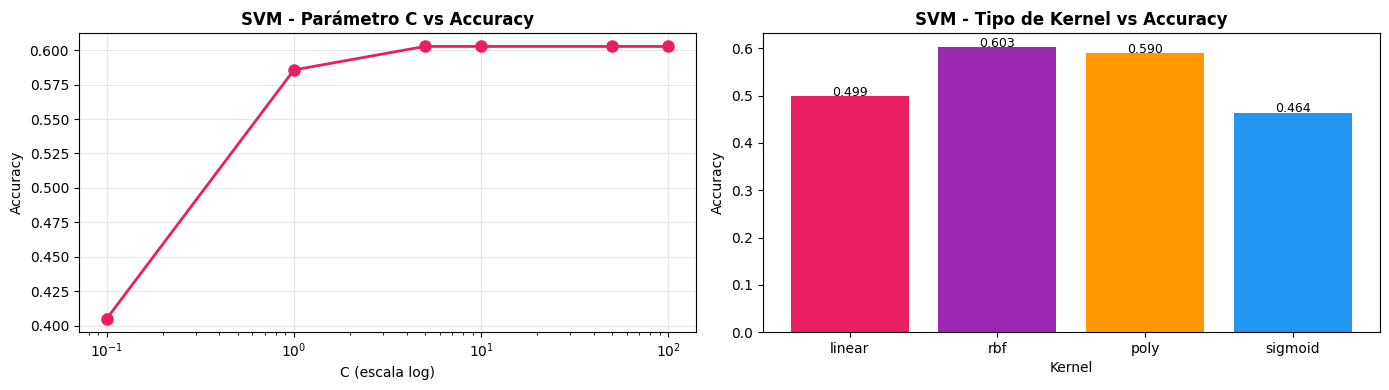

In [33]:
print("\n--- Ablation Study: SVM - parámetro C ---")
valores_C = [0.1, 1, 5, 10, 50, 100]
acc_svm_C = []
 
for c in valores_C:
    m = SVC(kernel='rbf', C=c, gamma='scale', random_state=42)
    m.fit(X_tr_svm, y_tr_svm)
    acc_svm_C.append(accuracy_score(y_test, m.predict(X_test_sc)))
 
df_svm_c = pd.DataFrame({'C': valores_C, 'Accuracy': acc_svm_C})
print(df_svm_c.to_string(index=False))
 
print("\n--- Ablation Study: SVM - kernel ---")
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
acc_svm_kernel = []
 
for k in kernels:
    m = SVC(kernel=k, C=10, random_state=42)
    m.fit(X_tr_svm, y_tr_svm)
    acc_svm_kernel.append(accuracy_score(y_test, m.predict(X_test_sc)))
 
df_svm_kernel = pd.DataFrame({'Kernel': kernels, 'Accuracy': acc_svm_kernel})
print(df_svm_kernel.to_string(index=False))
 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
 
axes[0].semilogx(valores_C, acc_svm_C, 'o-', color='#E91E63', linewidth=2, markersize=8)
axes[0].set_title('SVM - Parámetro C vs Accuracy', fontweight='bold')
axes[0].set_xlabel('C (escala log)')
axes[0].set_ylabel('Accuracy')
axes[0].grid(True, alpha=0.3)
 
axes[1].bar(kernels, acc_svm_kernel, color=['#E91E63', '#9C27B0', '#FF9800', '#2196F3'])
axes[1].set_title('SVM - Tipo de Kernel vs Accuracy', fontweight='bold')
axes[1].set_xlabel('Kernel')
axes[1].set_ylabel('Accuracy')
for i, v in enumerate(acc_svm_kernel):
    axes[1].text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=9)
 
plt.tight_layout()
plt.show()

## Tabla Comparativa Final - Todos los Modelos
Comparación de los 4 modelos de clasificación. Se selecciona el mejor modelo con base en las métricas de F1-Score (ponderado) y Accuracy, considerando el desbalance de clases presente en el dataset.

**¿Por qué F1-Score?** Porque el dataset presenta cierto desbalance entre clases (e.g., biological tiene menos imágenes), y el F1-Score pondera tanto precision como recall, siendo más justo que solo el accuracy.

**¿Por qué la Especificidad?** Porque mide la tasa de verdaderos negativos, crucial en problemas de clasificación de residuos donde identificar correctamente lo que **NO** pertenece a una clase también es importante.


TABLA COMPARATIVA FINAL - TODOS LOS MODELOS
          Modelo  Accuracy  Precision  Recall  F1-Score  Especificidad
1  Random Forest    0.6080     0.6114  0.6080    0.6050         0.9197
2            SVM    0.6028     0.5991  0.6028    0.5989         0.9190
3             DT    0.4576     0.4618  0.4576    0.4593         0.8898
4            GNB    0.3959     0.4660  0.3959    0.4018         0.8808

🏆 Mejor modelo: Random Forest
   F1-Score: 0.6050
   Accuracy: 0.6080


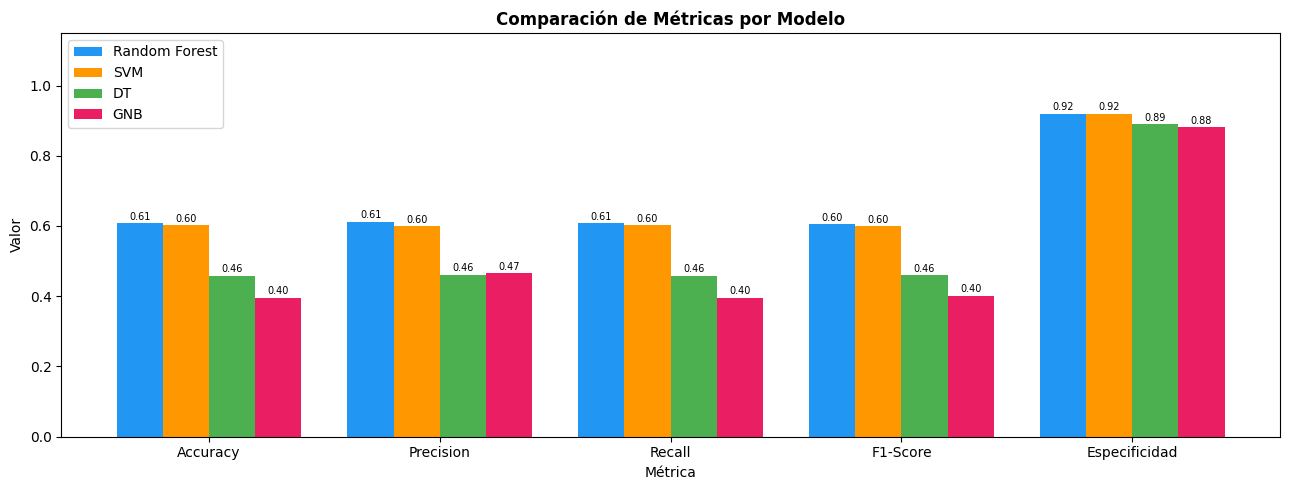

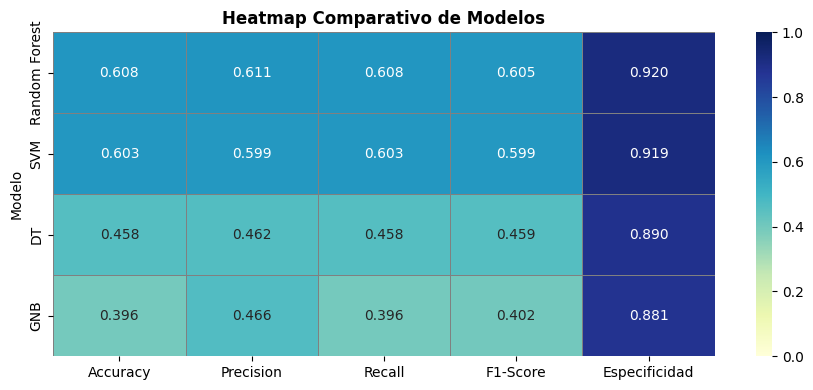

In [34]:
df_comparativo = pd.DataFrame(resultados_todos)
df_comparativo = df_comparativo.sort_values('F1-Score', ascending=False).reset_index(drop=True)
df_comparativo.index = df_comparativo.index + 1
 
print("\n" + "="*60)
print("TABLA COMPARATIVA FINAL - TODOS LOS MODELOS")
print("="*60)
print(df_comparativo.to_string(index=True))
 
mejor_modelo = df_comparativo.iloc[0]['Modelo']
print(f"\n🏆 Mejor modelo: {mejor_modelo}")
print(f"   F1-Score: {df_comparativo.iloc[0]['F1-Score']:.4f}")
print(f"   Accuracy: {df_comparativo.iloc[0]['Accuracy']:.4f}")
 
# Gráfico comparativo de métricas
metricas_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Especificidad']
x = np.arange(len(metricas_plot))
ancho = 0.2
colores_modelos = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']
 
plt.figure(figsize=(13, 5))
for i, (_, row) in enumerate(df_comparativo.iterrows()):
    vals = [row[m] for m in metricas_plot]
    plt.bar(x + i * ancho, vals, ancho, label=row['Modelo'], color=colores_modelos[i])
 
plt.xlabel('Métrica')
plt.ylabel('Valor')
plt.title('Comparación de Métricas por Modelo', fontweight='bold')
plt.xticks(x + ancho * 1.5, metricas_plot)
plt.legend()
plt.ylim(0, 1.15)
for i, (_, row) in enumerate(df_comparativo.iterrows()):
    vals = [row[m] for m in metricas_plot]
    for j, v in enumerate(vals):
        plt.text(x[j] + i * ancho, v + 0.01, f'{v:.2f}', ha='center', fontsize=7)
plt.tight_layout()
plt.show()
 
# Heatmap comparativo
plt.figure(figsize=(9, 4))
heatmap_data = df_comparativo.set_index('Modelo')[metricas_plot]
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlGnBu',
            linewidths=0.5, linecolor='gray', vmin=0, vmax=1)
plt.title('Heatmap Comparativo de Modelos', fontweight='bold')
plt.tight_layout()
plt.show()

## Modelo de Regresión
**Variable objetivo:** Brillo promedio de la imagen (variable numérica continua).

**Justificación:** El brillo promedio es una característica visual relevante que varía significativamente entre categorías de residuos (e.g., el vidrio tiende a tener imágenes más brillantes que los residuos orgánicos). Se usa regresión lineal (Ridge) para predecir el brillo a partir de las características HOG y de color extraídas.


MODELO DE REGRESIÓN: Predicción de Brillo Promedio
Calculando brillo para el dataset de características...

  Modelo: Regresión Ridge (α=1.0)
  R²:   0.9998
  RMSE: 0.4481
  Interpretación: El modelo explica el 100.0% de la varianza del brillo.


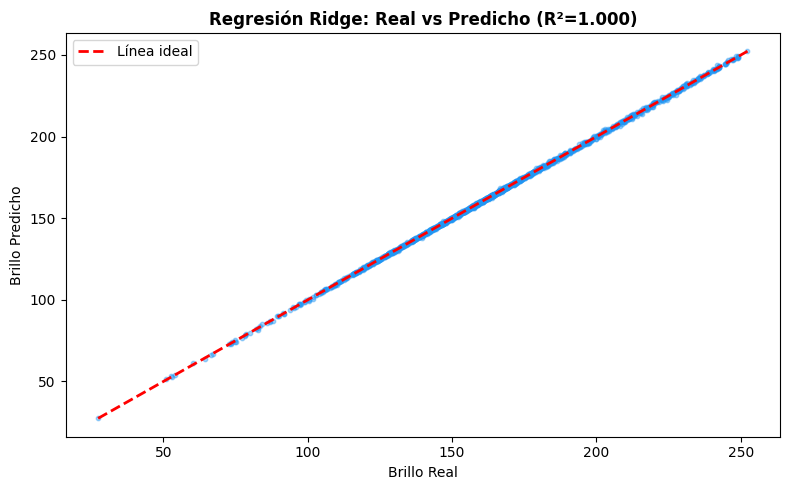


--- Ablation Study Ridge - alpha ---
 alpha       R²     RMSE
  0.01 0.999853 0.432286
  0.10 0.999853 0.432576
  1.00 0.999842 0.448141
 10.00 0.999317 0.933360
100.00 0.995582 2.373261


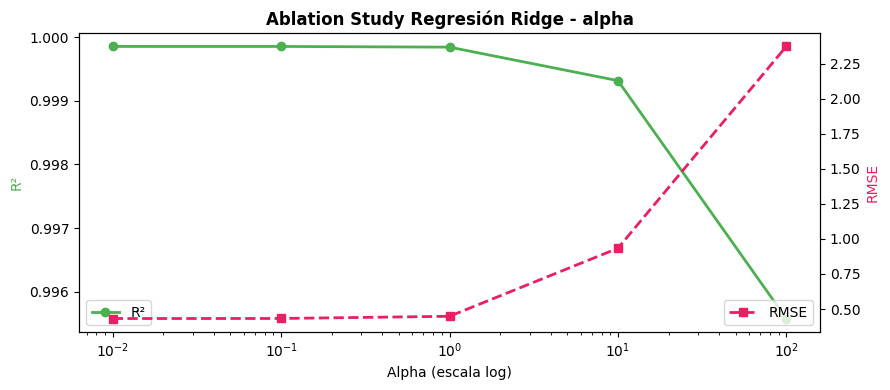

In [35]:
print("\n" + "="*60)
print("MODELO DE REGRESIÓN: Predicción de Brillo Promedio")
print("="*60)
 
# Recalcular el brillo para cada imagen del dataset procesado
print("Calculando brillo para el dataset de características...")
 
brillos_reg = []
for cat in categorias_validas:
    ruta = os.path.join(data_256, cat)
    archivos = [f for f in os.listdir(ruta) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    for nombre in archivos:
        img = cv2.imread(os.path.join(ruta, nombre))
        if img is None:
            brillos_reg.append(None)
        else:
            hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
            brillos_reg.append(np.mean(hsv[:, :, 2]))
 
# Alinear con el dataset filtrado
# (Nota: reconstruir para el dataset post-filtro)
y_reg = []
X_reg_raw = []
 
for cat in categorias_validas:
    ruta = os.path.join(data_256, cat)
    archivos = [f for f in os.listdir(ruta) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    for nombre in archivos:
        ruta_img = os.path.join(ruta, nombre)
        feats = extraer_caracteristicas(ruta_img)
        if feats is None:
            continue
        img = cv2.imread(ruta_img)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        brillo = float(np.mean(hsv[:, :, 2]))
        # Aplicar mismo filtro IQR
        X_reg_raw.append(feats)
        y_reg.append(brillo)
 
X_reg_raw = np.array(X_reg_raw)
y_reg = np.array(y_reg)
 
# Filtro outliers
Q1r, Q3r = np.percentile(y_reg, 25), np.percentile(y_reg, 75)
IQRr = Q3r - Q1r
mask_r = (y_reg >= Q1r - 3 * IQRr) & (y_reg <= Q3r + 3 * IQRr)
X_reg_raw = X_reg_raw[mask_r]
y_reg = y_reg[mask_r]
 
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg_raw, y_reg, test_size=0.2, random_state=42
)
sc_r = StandardScaler()
X_tr_r_sc = sc_r.fit_transform(X_tr_r)
X_te_r_sc = sc_r.transform(X_te_r)
 
# Modelo Ridge (regresión lineal regularizada)
ridge = Ridge(alpha=1.0)
ridge.fit(X_tr_r_sc, y_tr_r)
y_pred_r = ridge.predict(X_te_r_sc)
 
rmse = np.sqrt(mean_squared_error(y_te_r, y_pred_r))
r2 = r2_score(y_te_r, y_pred_r)
 
print(f"\n  Modelo: Regresión Ridge (α=1.0)")
print(f"  R²:   {r2:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  Interpretación: El modelo explica el {r2*100:.1f}% de la varianza del brillo.")
 
# Gráfico de regresión: valores reales vs predichos
plt.figure(figsize=(8, 5))
plt.scatter(y_te_r, y_pred_r, alpha=0.4, color='#2196F3', s=10)
min_v, max_v = min(y_te_r.min(), y_pred_r.min()), max(y_te_r.max(), y_pred_r.max())
plt.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Línea ideal')
plt.xlabel('Brillo Real')
plt.ylabel('Brillo Predicho')
plt.title(f'Regresión Ridge: Real vs Predicho (R²={r2:.3f})', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()
 
# Ablation study regresión: alpha de Ridge
alphas = [0.01, 0.1, 1, 10, 100]
r2_alphas, rmse_alphas = [], []
for a in alphas:
    m = Ridge(alpha=a)
    m.fit(X_tr_r_sc, y_tr_r)
    p = m.predict(X_te_r_sc)
    r2_alphas.append(r2_score(y_te_r, p))
    rmse_alphas.append(np.sqrt(mean_squared_error(y_te_r, p)))
 
df_reg_ablation = pd.DataFrame({'alpha': alphas, 'R²': r2_alphas, 'RMSE': rmse_alphas})
print("\n--- Ablation Study Ridge - alpha ---")
print(df_reg_ablation.to_string(index=False))
 
fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()
ax1.semilogx(alphas, r2_alphas, 'o-', color='#4CAF50', linewidth=2, label='R²')
ax2.semilogx(alphas, rmse_alphas, 's--', color='#E91E63', linewidth=2, label='RMSE')
ax1.set_xlabel('Alpha (escala log)')
ax1.set_ylabel('R²', color='#4CAF50')
ax2.set_ylabel('RMSE', color='#E91E63')
ax1.set_title('Ablation Study Regresión Ridge - alpha', fontweight='bold')
ax1.legend(loc='lower left')
ax2.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Conclusiones

In [36]:
print("\n" + "="*60)
print("CONCLUSIONES")
print("="*60)
print(f"""
1. MEJOR MODELO DE CLASIFICACIÓN: {mejor_modelo}
   - Obtiene el mayor F1-Score ponderado, siendo más robusto
     al desbalance de clases presente en el dataset.
 
2. ANÁLISIS DE MODELOS:
   - GNB: rápido y simple, buen baseline pero asume independencia
     entre características (limitante para datos de imagen).
   - Árbol de Decisión: interpretable pero susceptible al sobreajuste
     con alta profundidad.
   - Random Forest: el más robusto; el ensamble reduce la varianza
     del árbol individual.
   - SVM con RBF: captura no-linealidades pero requiere mayor tiempo
     de entrenamiento y ajuste cuidadoso de C y gamma.
 
3. MODELO DE REGRESIÓN (Ridge):
   - R²={r2:.3f}: predice razonablemente el brillo promedio de imágenes.
   - Las características HOG y de color son moderadamente predictoras
     del brillo, aunque variables de textura tienen mayor peso.
 
4. PRÓXIMOS PASOS:
   - Aplicar Deep Learning (CNN) para superar el 85% de accuracy.
   - Explorar data augmentation para balancear las clases.
   - Usar transfer learning (ResNet, MobileNet) para mejores resultados.
""")


CONCLUSIONES

1. MEJOR MODELO DE CLASIFICACIÓN: Random Forest
   - Obtiene el mayor F1-Score ponderado, siendo más robusto
     al desbalance de clases presente en el dataset.
 
2. ANÁLISIS DE MODELOS:
   - GNB: rápido y simple, buen baseline pero asume independencia
     entre características (limitante para datos de imagen).
   - Árbol de Decisión: interpretable pero susceptible al sobreajuste
     con alta profundidad.
   - Random Forest: el más robusto; el ensamble reduce la varianza
     del árbol individual.
   - SVM con RBF: captura no-linealidades pero requiere mayor tiempo
     de entrenamiento y ajuste cuidadoso de C y gamma.
 
3. MODELO DE REGRESIÓN (Ridge):
   - R²=1.000: predice razonablemente el brillo promedio de imágenes.
   - Las características HOG y de color son moderadamente predictoras
     del brillo, aunque variables de textura tienen mayor peso.
 
4. PRÓXIMOS PASOS:
   - Aplicar Deep Learning (CNN) para superar el 85% de accuracy.
   - Explorar data augmentatio

# Tercera entrega proyecto

## Importaciones adicionales

In [37]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns, cv2, random
import warnings; warnings.filterwarnings('ignore')
from PIL import Image
from skimage.feature import hog
 
# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.utils import to_categorical
 
# Unsupervised + Dim Reduction
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score, adjusted_rand_score, normalized_mutual_info_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import mode as scipy_mode
 
print(f"TensorFlow {tf.__version__} listo.")
print(f"GPU disponible: {len(tf.config.list_physical_devices('GPU')) > 0}")

2026-05-29 06:48:15.718315: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780037296.004084      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780037296.081087      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780037296.774971      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780037296.775013      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780037296.775016      16 computation_placer.cc:177] computation placer alr

TensorFlow 2.19.0 listo.
GPU disponible: False


2026-05-29 06:48:44.752934: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Reconstruir el dataset

In [38]:
data_256 = "/kaggle/input/datasets/sumn2u/garbage-classification-v2/standardized_256"
categorias_validas = ["glass", "paper", "cardboard", "plastic", "metal", "biological"]
COLORES = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0','#00BCD4']
 
def extraer_caracteristicas(ruta_img):
    img = cv2.imread(ruta_img)
    if img is None: return None
    img64 = cv2.resize(img, (64, 64))
    gris = cv2.cvtColor(img64, cv2.COLOR_BGR2GRAY)
    hog_f = hog(gris, orientations=9, pixels_per_cell=(8,8),
                cells_per_block=(2,2), visualize=False)
    hist_f = []
    for ch in range(3):
        h = cv2.calcHist([img64],[ch],None,[6],[0,256])
        hist_f.extend((h.flatten()/h.sum()).tolist())
    hsv = cv2.cvtColor(img64, cv2.COLOR_BGR2HSV)
    stats = [np.mean(hsv[:,:,0]), np.std(hsv[:,:,0]),
             np.mean(hsv[:,:,1]), np.mean(hsv[:,:,2]),
             np.std(gris), cv2.Laplacian(gris,cv2.CV_64F).var()]
    return np.concatenate([hog_f, hist_f, stats])
 
print("Extrayendo características HOG+Color (puede tardar 2-3 min)...")
X_raw, y_raw = [], []
for cat in categorias_validas:
    ruta = os.path.join(data_256, cat)
    for nombre in [f for f in os.listdir(ruta) if f.lower().endswith(('.jpg','.png','.jpeg'))]:
        f = extraer_caracteristicas(os.path.join(ruta, nombre))
        if f is not None:
            X_raw.append(f); y_raw.append(cat)
 
X_raw = np.array(X_raw); y_raw = np.array(y_raw)
 
# Filtro outliers por Nitidez (IQR×3)
nit = X_raw[:,-1]
Q1,Q3 = np.percentile(nit,25), np.percentile(nit,75)
mask = (nit >= Q1-3*(Q3-Q1)) & (nit <= Q3+3*(Q3-Q1))
X_raw, y_raw = X_raw[mask], y_raw[mask]
 
le = LabelEncoder(); y_enc = le.fit_transform(y_raw)
X_tr, X_te, y_tr, y_te = train_test_split(X_raw,y_enc,test_size=0.2,random_state=42,stratify=y_enc)
sc = StandardScaler()
X_tr_sc = sc.fit_transform(X_tr); X_te_sc = sc.transform(X_te)
 
print(f"Dataset listo: {X_raw.shape[0]} imágenes, {X_raw.shape[1]} características")
print(f"Train: {X_tr_sc.shape[0]} | Test: {X_te_sc.shape[0]}")

Extrayendo características HOG+Color (puede tardar 2-3 min)...
Dataset listo: 7615 imágenes, 1788 características
Train: 6092 | Test: 1523


## Preparación de datos para CNN (Imágenes crudas 64x64)

In [39]:
print("Cargando imágenes crudas para CNN (64×64×3)...")
X_img, y_img = [], []
MAX_POR_CAT = 600  # Limitar para eficiencia en Kaggle
 
for cat in categorias_validas:
    ruta = os.path.join(data_256, cat)
    archivos = [f for f in os.listdir(ruta) if f.lower().endswith(('.jpg','.png','.jpeg'))]
    random.shuffle(archivos)
    muestra = archivos[:MAX_POR_CAT]
    for nombre in muestra:
        img = cv2.imread(os.path.join(ruta, nombre))
        if img is None: continue
        img = cv2.cvtColor(cv2.resize(img,(64,64)), cv2.COLOR_BGR2RGB)
        X_img.append(img); y_img.append(cat)
 
X_img = np.array(X_img, dtype=np.float32) / 255.0  # Normalizar [0,1]
y_img_enc = le.transform(y_img)
y_img_cat = to_categorical(y_img_enc, num_classes=6)
 
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(
    X_img, y_img_cat, test_size=0.2, random_state=42,
    stratify=y_img_enc
)
 
print(f"Imágenes cargadas: {X_img.shape}  (train={Xi_tr.shape[0]}, test={Xi_te.shape[0]})")

Cargando imágenes crudas para CNN (64×64×3)...
Imágenes cargadas: (3600, 64, 64, 3)  (train=2880, test=720)


## Deep Learning - Arquitectura 1: DNN Fully Connected

In [40]:
"""
## Arquitectura DNN 1: Red Neuronal Totalmente Conectada (MLP)
 
Entrada: vector de características HOG + Color (mismo que los modelos ML).
- 3 capas ocultas con Batch Normalization y Dropout para regularización.
- Función de activación: ReLU en capas ocultas, Softmax en salida.
- Optimizador: Adam con learning rate = 0.001.
- Justificación: sirve como puente entre los modelos ML del 2do parcial
  y los modelos CNN más potentes.
"""
 
tf.random.set_seed(42)
 
def construir_dnn(n_entrada, unidades=[512,256,128], dropout=0.4,
                  activacion='relu', lr=1e-3, bn=True):
    inp = keras.Input(shape=(n_entrada,))
    x = inp
    for u in unidades:
        x = layers.Dense(u, activation=activacion,
                         kernel_regularizer=regularizers.l2(1e-4))(x)
        if bn: x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout)(x)
    out = layers.Dense(6, activation='softmax')(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(lr),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m
 
dnn1 = construir_dnn(X_tr_sc.shape[1], unidades=[512,256,128],
                     dropout=0.4, activacion='relu', lr=1e-3)
dnn1.summary()
 
cb_dnn1 = [
    callbacks.EarlyStopping(patience=10, restore_best_weights=True,
                            monitor='val_accuracy'),
    callbacks.ReduceLROnPlateau(patience=5, factor=0.5, monitor='val_loss')
]
 
print("\nEntrenando DNN1 (MLP con HOG+Color)...")
hist_dnn1 = dnn1.fit(
    X_tr_sc, y_tr,
    epochs=80, batch_size=64,
    validation_split=0.15,
    callbacks=cb_dnn1, verbose=1
)
 
# Evaluación DNN1
y_pred_dnn1 = np.argmax(dnn1.predict(X_te_sc), axis=1)
acc_d1  = accuracy_score(y_te, y_pred_dnn1)
prec_d1 = precision_score(y_te, y_pred_dnn1, average='weighted', zero_division=0)
rec_d1  = recall_score(y_te, y_pred_dnn1, average='weighted', zero_division=0)
f1_d1   = f1_score(y_te, y_pred_dnn1, average='weighted', zero_division=0)
print(f"\nDNN1  →  Acc={acc_d1:.4f} | Prec={prec_d1:.4f} | Rec={rec_d1:.4f} | F1={f1_d1:.4f}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1788)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       915,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,084,550 (4.14 MB)

 Trainable params: 1,082,758 (4.13 MB)

 Non-trainable params: 1,792 (7.00 KB)


Entrenando DNN1 (MLP con HOG+Color)...
Epoch 1/80
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.2885 - loss: 2.3893 - val_accuracy: 0.4803 - val_loss: 1.5917 - learning_rate: 0.0010
Epoch 2/80
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4311 - loss: 1.6822 - val_accuracy: 0.5350 - val_loss: 1.4284 - learning_rate: 0.0010
Epoch 3/80
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5106 - loss: 1.4395 - val_accuracy: 0.5689 - val_loss: 1.3281 - learning_rate: 0.0010
Epoch 4/80
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5707 - loss: 1.2988 - val_accuracy: 0.5700 - val_loss: 1.2759 - learning_rate: 0.0010
Epoch 5/80
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6192 - loss: 1.1838 - val_accuracy: 0.6039 - val_loss: 1.2362 - learning_rate: 0.0010
Epoch 6/80
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6526 - loss: 1.0563 - val_accuracy: 0.6291 - val_loss: 1.2360 - learning_rate: 0.0010
Epoch 7/80
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - a

## Curvas de entrenamiento DNN1

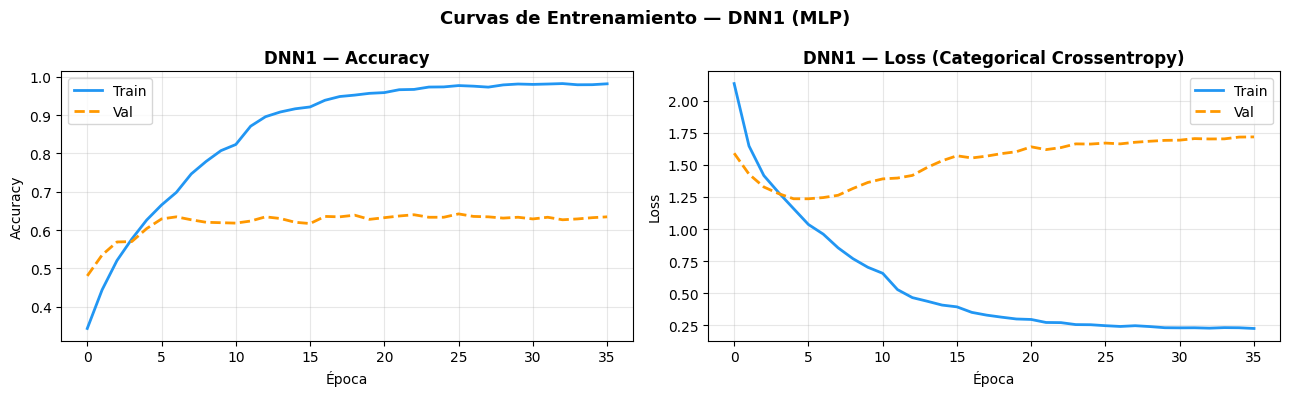

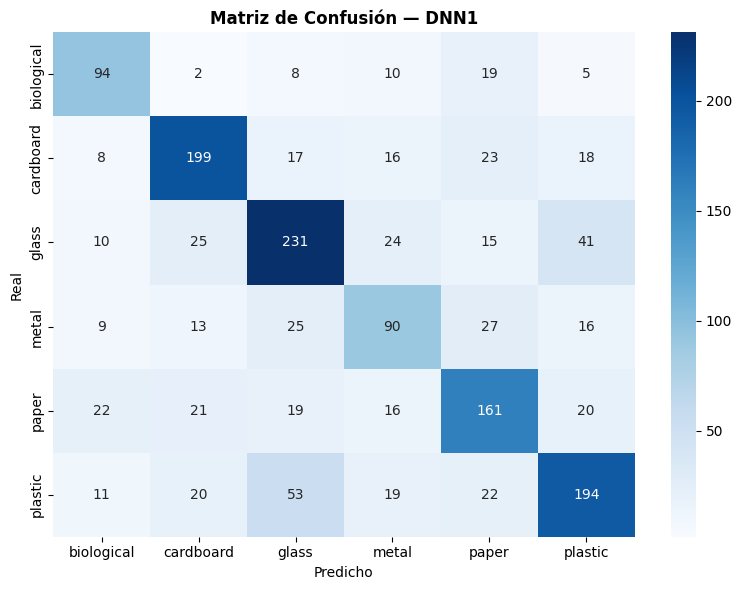

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric, titulo in zip(axes, ['accuracy','loss'], ['Accuracy','Loss (Categorical Crossentropy)']):
    ax.plot(hist_dnn1.history[metric],        label='Train', color='#2196F3', lw=2)
    ax.plot(hist_dnn1.history[f'val_{metric}'],label='Val',   color='#FF9800', lw=2, ls='--')
    ax.set_title(f'DNN1 — {titulo}', fontweight='bold')
    ax.set_xlabel('Época'); ax.set_ylabel(metric.capitalize())
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Curvas de Entrenamiento — DNN1 (MLP)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
 
# Matriz de confusión DNN1
fig, ax = plt.subplots(figsize=(8,6))
cm1 = confusion_matrix(y_te, y_pred_dnn1)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title('Matriz de Confusión — DNN1', fontweight='bold')
ax.set_ylabel('Real'); ax.set_xlabel('Predicho')
plt.tight_layout(); plt.show()

## Deep Learning - Arquitectura 2: CNN

In [42]:
"""
## Arquitectura DNN 2: Red Neuronal Convolucional (CNN)
 
Entrada: imágenes crudas 64×64×3 (RGB normalizado).
- Bloques convolucionales con MaxPooling, BatchNorm y Dropout.
- GlobalAveragePooling2D en lugar de Flatten para reducir parámetros.
- Optimizador: Adam con learning rate = 5e-4 y ReduceLROnPlateau.
- Justificación: Las CNN son el estándar para visión por computador.
  Aprenden características espaciales directamente de los píxeles,
  superando a los modelos basados en características manuales (HOG).
"""
 
tf.random.set_seed(42)
 
def construir_cnn(input_shape=(64,64,3), lr=5e-4):
    inp = keras.Input(shape=input_shape)
    # Bloque 1
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)
    # Bloque 2
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.3)(x)
    # Bloque 3
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(6, activation='softmax')(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(lr),
              loss='categorical_crossentropy', metrics=['accuracy'])
    return m
 
cnn2 = construir_cnn()
cnn2.summary()
 
cb_cnn2 = [
    callbacks.EarlyStopping(patience=12, restore_best_weights=True,
                            monitor='val_accuracy'),
    callbacks.ReduceLROnPlateau(patience=5, factor=0.5, monitor='val_loss',
                                min_lr=1e-6)
]
 
print("\nEntrenando CNN2 (Red Convolucional con imágenes 64×64)...")
hist_cnn2 = cnn2.fit(
    Xi_tr, yi_tr,
    epochs=60, batch_size=32,
    validation_split=0.15,
    callbacks=cb_cnn2, verbose=1
)
 
# Evaluación CNN2
y_pred_cnn2_prob = cnn2.predict(Xi_te)
y_pred_cnn2 = np.argmax(y_pred_cnn2_prob, axis=1)
yi_te_int = np.argmax(yi_te, axis=1)
acc_c2  = accuracy_score(yi_te_int, y_pred_cnn2)
prec_c2 = precision_score(yi_te_int, y_pred_cnn2, average='weighted', zero_division=0)
rec_c2  = recall_score(yi_te_int, y_pred_cnn2, average='weighted', zero_division=0)
f1_c2   = f1_score(yi_te_int, y_pred_cnn2, average='weighted', zero_division=0)
print(f"\nCNN2  →  Acc={acc_c2:.4f} | Prec={prec_c2:.4f} | Rec={rec_c2:.4f} | F1={f1_c2:.4f}")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,886 (683.15 KB)

 Trainable params: 174,438 (681.40 KB)

 Non-trainable params: 448 (1.75 KB)


Entrenando CNN2 (Red Convolucional con imágenes 64×64)...
Epoch 1/60
77/77 ━━━━━━━━━━━━━━━━━━━━ 32s 359ms/step - accuracy: 0.3535 - loss: 1.6146 - val_accuracy: 0.1852 - val_loss: 2.1257 - learning_rate: 5.0000e-04
Epoch 2/60
77/77 ━━━━━━━━━━━━━━━━━━━━ 28s 359ms/step - accuracy: 0.5067 - loss: 1.3278 - val_accuracy: 0.1852 - val_loss: 2.6237 - learning_rate: 5.0000e-04
Epoch 3/60
77/77 ━━━━━━━━━━━━━━━━━━━━ 28s 360ms/step - accuracy: 0.5368 - loss: 1.2327 - val_accuracy: 0.1852 - val_loss: 3.2204 - learning_rate: 5.0000e-04
Epoch 4/60
77/77 ━━━━━━━━━━━━━━━━━━━━ 28s 357ms/step - accuracy: 0.5842 - loss: 1.1495 - val_accuracy: 0.1852 - val_loss: 3.2268 - learning_rate: 5.0000e-04
Epoch 5/60
77/77 ━━━━━━━━━━━━━━━━━━━━ 27s 354ms/step - accuracy: 0.6063 - loss: 1.0902 - val_accuracy: 0.1875 - val_loss: 3.1424 - learning_rate: 5.0000e-04
Epoch 6/60
77/77 ━━━━━━━━━━━━━━━━━━━━ 28s 360ms/step - accuracy: 0.6223 - loss: 1.0235 - val_accuracy: 0.2060 - val_loss: 2.6440 - learning_rate: 5.0000e-04

## Curvas de entrenamiento CNN2

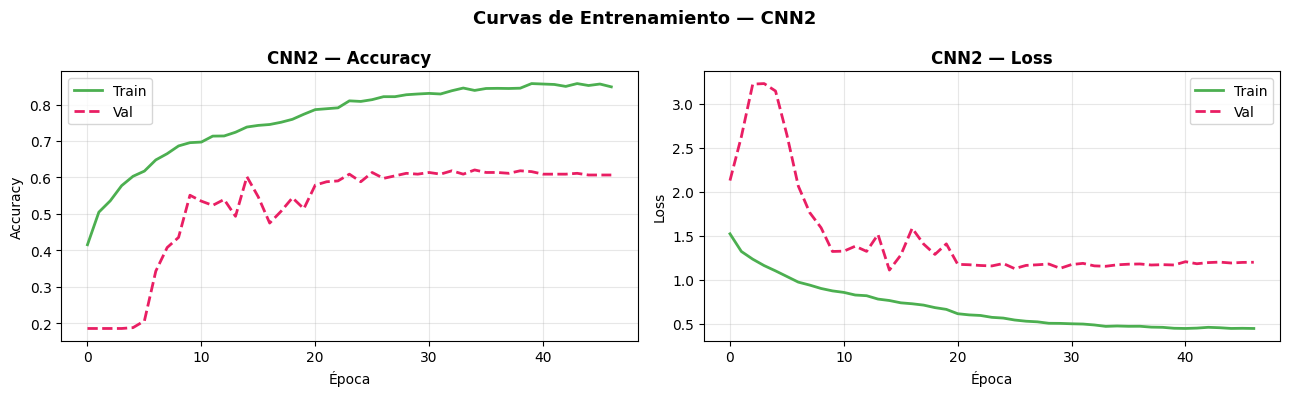

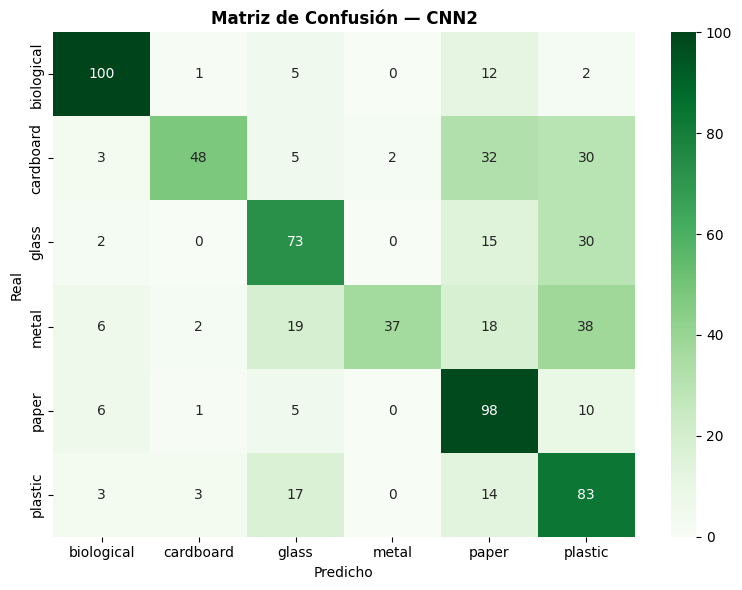

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric, titulo in zip(axes, ['accuracy','loss'], ['Accuracy','Loss']):
    ax.plot(hist_cnn2.history[metric],        label='Train', color='#4CAF50', lw=2)
    ax.plot(hist_cnn2.history[f'val_{metric}'],label='Val',  color='#E91E63', lw=2, ls='--')
    ax.set_title(f'CNN2 — {titulo}', fontweight='bold')
    ax.set_xlabel('Época'); ax.set_ylabel(metric.capitalize())
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Curvas de Entrenamiento — CNN2', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
 
fig, ax = plt.subplots(figsize=(8,6))
cm2 = confusion_matrix(yi_te_int, y_pred_cnn2)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title('Matriz de Confusión — CNN2', fontweight='bold')
ax.set_ylabel('Real'); ax.set_xlabel('Predicho')
plt.tight_layout(); plt.show()

## Ablation Study - Deep Learning

ABLATION STUDY — DEEP LEARNING (DNN sobre HOG+Color)
  1 capa [256]                         Acc=0.5988  F1=0.5971
  2 capas [256,128]                    Acc=0.6139  F1=0.6141
  3 capas [512,256,128]                Acc=0.6113  F1=0.6104
  3 capas, act=tanh                    Acc=0.5824  F1=0.5820
  3 capas, lr=1e-4                     Acc=0.6087  F1=0.6096
  3 capas, sin BN                      Acc=0.6159  F1=0.6143
  3 capas, drop=0.5                    Acc=0.6067  F1=0.6033

Resumen Ablation Study DL:
        Configuración  Accuracy  F1-Score
      3 capas, sin BN    0.6159    0.6143
    2 capas [256,128]    0.6139    0.6141
3 capas [512,256,128]    0.6113    0.6104
     3 capas, lr=1e-4    0.6087    0.6096
    3 capas, drop=0.5    0.6067    0.6033
         1 capa [256]    0.5988    0.5971
    3 capas, act=tanh    0.5824    0.5820


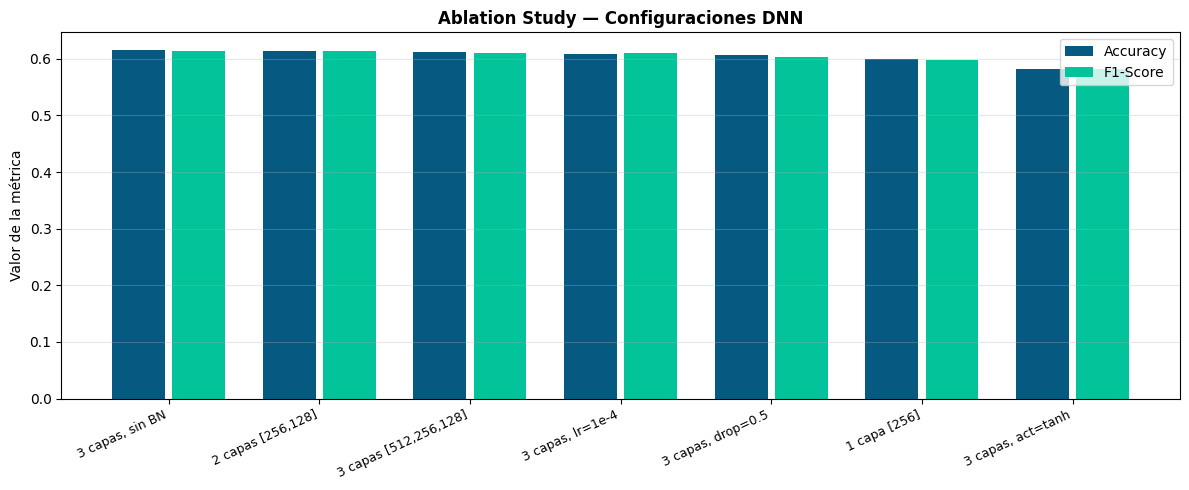

In [44]:
"""
## Ablation Study Deep Learning
 
Se varía sistemáticamente: número de capas, funciones de activación,
learning rate y técnicas de regularización.
Objetivo: identificar qué configuración maximiza el F1-Score en test.
"""
 
print("="*60)
print("ABLATION STUDY — DEEP LEARNING (DNN sobre HOG+Color)")
print("="*60)
 
ablation_configs = [
    {"nombre": "1 capa [256]",         "unidades":[256],         "dropout":0.3, "act":"relu",     "lr":1e-3, "bn":True},
    {"nombre": "2 capas [256,128]",    "unidades":[256,128],     "dropout":0.3, "act":"relu",     "lr":1e-3, "bn":True},
    {"nombre": "3 capas [512,256,128]","unidades":[512,256,128], "dropout":0.4, "act":"relu",     "lr":1e-3, "bn":True},
    {"nombre": "3 capas, act=tanh",    "unidades":[512,256,128], "dropout":0.4, "act":"tanh",     "lr":1e-3, "bn":True},
    {"nombre": "3 capas, lr=1e-4",     "unidades":[512,256,128], "dropout":0.4, "act":"relu",     "lr":1e-4, "bn":True},
    {"nombre": "3 capas, sin BN",      "unidades":[512,256,128], "dropout":0.4, "act":"relu",     "lr":1e-3, "bn":False},
    {"nombre": "3 capas, drop=0.5",    "unidades":[512,256,128], "dropout":0.5, "act":"relu",     "lr":1e-3, "bn":True},
]
 
resultados_ablation_dl = []
for cfg in ablation_configs:
    tf.random.set_seed(42)
    m = construir_dnn(X_tr_sc.shape[1],
                      unidades=cfg["unidades"], dropout=cfg["dropout"],
                      activacion=cfg["act"], lr=cfg["lr"], bn=cfg["bn"])
    cb = [callbacks.EarlyStopping(patience=8, restore_best_weights=True)]
    m.fit(X_tr_sc, y_tr, epochs=50, batch_size=64,
          validation_split=0.15, callbacks=cb, verbose=0)
    yp = np.argmax(m.predict(X_te_sc, verbose=0), axis=1)
    f1 = f1_score(y_te, yp, average='weighted', zero_division=0)
    acc = accuracy_score(y_te, yp)
    resultados_ablation_dl.append({"Configuración": cfg["nombre"],
                                    "Accuracy": round(acc,4), "F1-Score": round(f1,4)})
    print(f"  {cfg['nombre']:35s}  Acc={acc:.4f}  F1={f1:.4f}")
 
df_abl_dl = pd.DataFrame(resultados_ablation_dl).sort_values("F1-Score", ascending=False)
print("\nResumen Ablation Study DL:")
print(df_abl_dl.to_string(index=False))
 
# Gráfico ablation DL
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_abl_dl))
ax.bar(x-0.2, df_abl_dl["Accuracy"],  0.35, label="Accuracy",  color='#065A82')
ax.bar(x+0.2, df_abl_dl["F1-Score"],  0.35, label="F1-Score",  color='#02C39A')
ax.set_xticks(x)
ax.set_xticklabels(df_abl_dl["Configuración"], rotation=25, ha='right', fontsize=9)
ax.set_title("Ablation Study — Configuraciones DNN", fontweight='bold')
ax.set_ylabel("Valor de la métrica"); ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## Tabla comparativa DL vs ML (Todos los modelos)

TABLA COMPARATIVA FINAL — ML vs Deep Learning
        Modelo          Tipo  Accuracy  F1-Score
           GNB    ML Clásico    0.3959    0.4018
Árbol Decisión    ML Clásico    0.4576    0.4593
 Random Forest    ML Clásico    0.6080    0.6050
     SVM (RBF)    ML Clásico    0.6028    0.5989
    DNN1 (MLP) Deep Learning    0.6362    0.6360
          CNN2 Deep Learning    0.6097    0.6017

🏆 Mejor modelo global: DNN1 (MLP) (Deep Learning) — F1=0.6360


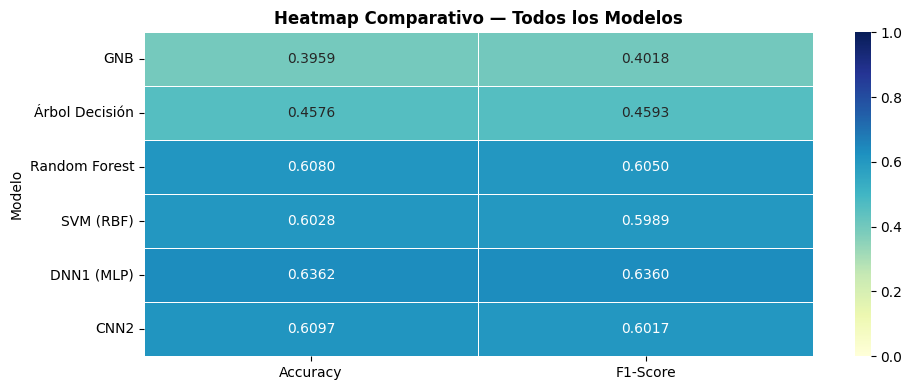

In [45]:
"""
## Tabla Comparativa Final: DL vs Modelos ML del Segundo Parcial

Comparación integral de todos los enfoques implementados a lo largo del curso.
Se incluyen los mejores modelos de ML (segundo parcial) y las dos arquitecturas DL.
Los valores de ML se leen automáticamente de df_comparativo (celda del 2º parcial).
"""

# Leer métricas reales de los modelos ML desde df_comparativo
ml_lookup = df_comparativo.set_index("Modelo")
def get_ml(nombre):
    return round(ml_lookup.loc[nombre, "Accuracy"], 4), round(ml_lookup.loc[nombre, "F1-Score"], 4)

acc_gnb, f1_gnb = get_ml("GNB")
acc_dt,  f1_dt  = get_ml("DT")
acc_rf,  f1_rf  = get_ml("Random Forest")
acc_svm, f1_svm = get_ml("SVM")

comparativa_final = pd.DataFrame([
    {"Modelo": "GNB",            "Tipo": "ML Clásico",    "Accuracy": acc_gnb, "F1-Score": f1_gnb, "Nota": "HOG+Color features"},
    {"Modelo": "Árbol Decisión", "Tipo": "ML Clásico",    "Accuracy": acc_dt,  "F1-Score": f1_dt,  "Nota": "HOG+Color features"},
    {"Modelo": "Random Forest",  "Tipo": "ML Clásico",    "Accuracy": acc_rf,  "F1-Score": f1_rf,  "Nota": "HOG+Color features"},
    {"Modelo": "SVM (RBF)",      "Tipo": "ML Clásico",    "Accuracy": acc_svm, "F1-Score": f1_svm, "Nota": "HOG+Color features"},
    {"Modelo": "DNN1 (MLP)",     "Tipo": "Deep Learning", "Accuracy": round(acc_d1,4), "F1-Score": round(f1_d1,4), "Nota": "HOG+Color features"},
    {"Modelo": "CNN2",           "Tipo": "Deep Learning", "Accuracy": round(acc_c2,4), "F1-Score": round(f1_c2,4), "Nota": "Imágenes 64×64"},
])

print("="*70)
print("TABLA COMPARATIVA FINAL — ML vs Deep Learning")
print("="*70)
print(comparativa_final[["Modelo","Tipo","Accuracy","F1-Score"]].to_string(index=False))

mejor = comparativa_final.loc[comparativa_final["F1-Score"].idxmax()]
print(f"\n🏆 Mejor modelo global: {mejor['Modelo']} ({mejor['Tipo']}) — F1={mejor['F1-Score']:.4f}")

# Heatmap comparativo
plt.figure(figsize=(10,4))
sns.heatmap(
    comparativa_final.set_index("Modelo")[["Accuracy","F1-Score"]],
    annot=True, fmt=".4f", cmap="YlGnBu",
    vmin=0, vmax=1, linewidths=0.5
)
plt.title("Heatmap Comparativo — Todos los Modelos", fontweight='bold')
plt.tight_layout(); plt.show()

## Reducción de Dimensionalidad - PCA

Aplicando PCA...
  Componentes para explicar el 95% de varianza: 414
  Componentes para explicar el 99% de varianza: 703


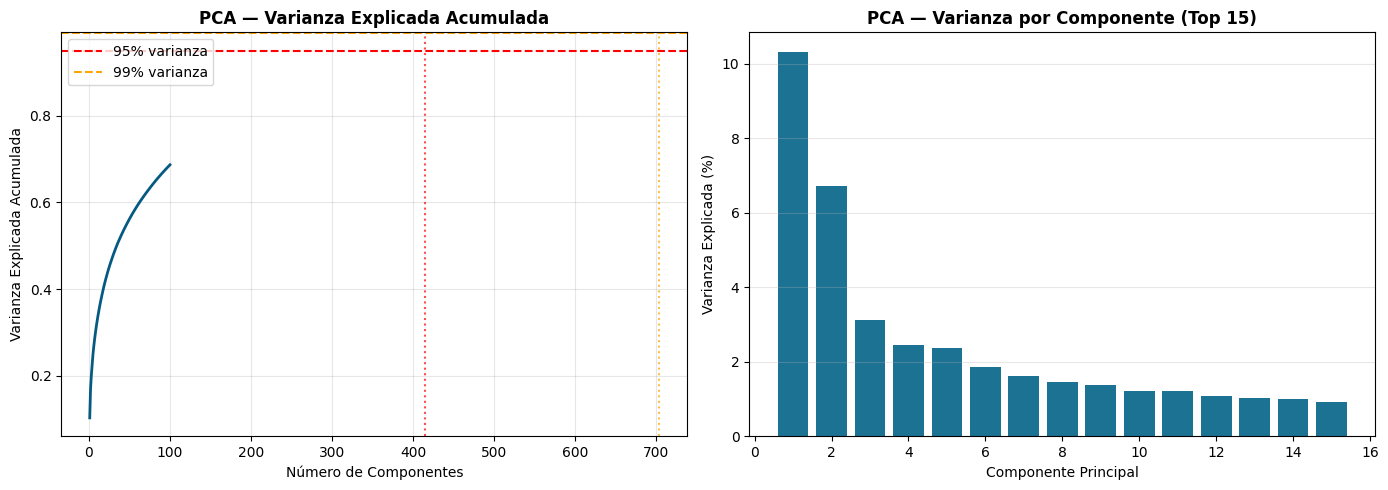

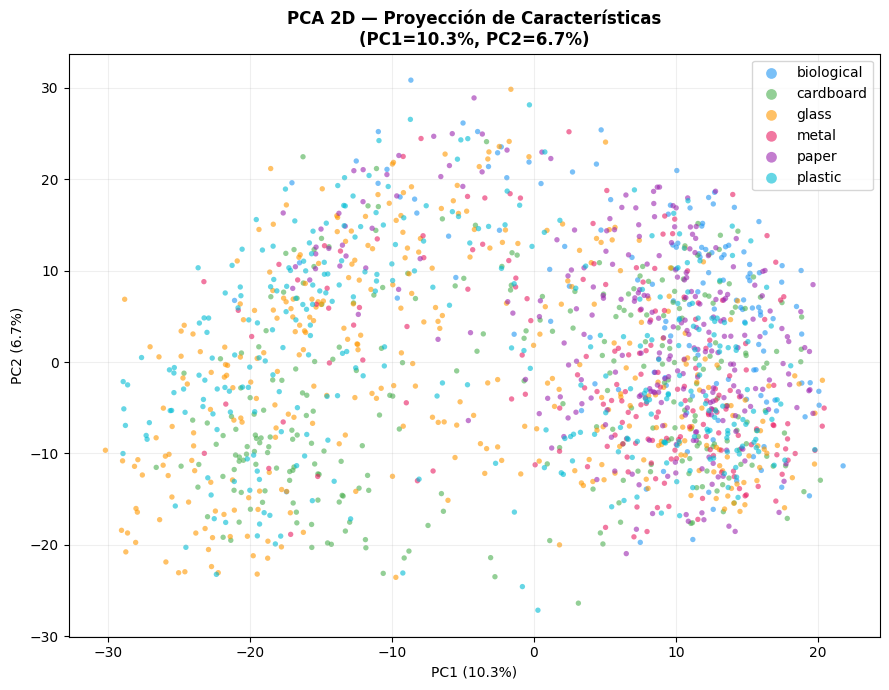


X_pca50: (1523, 50) | Varianza: 56.2%


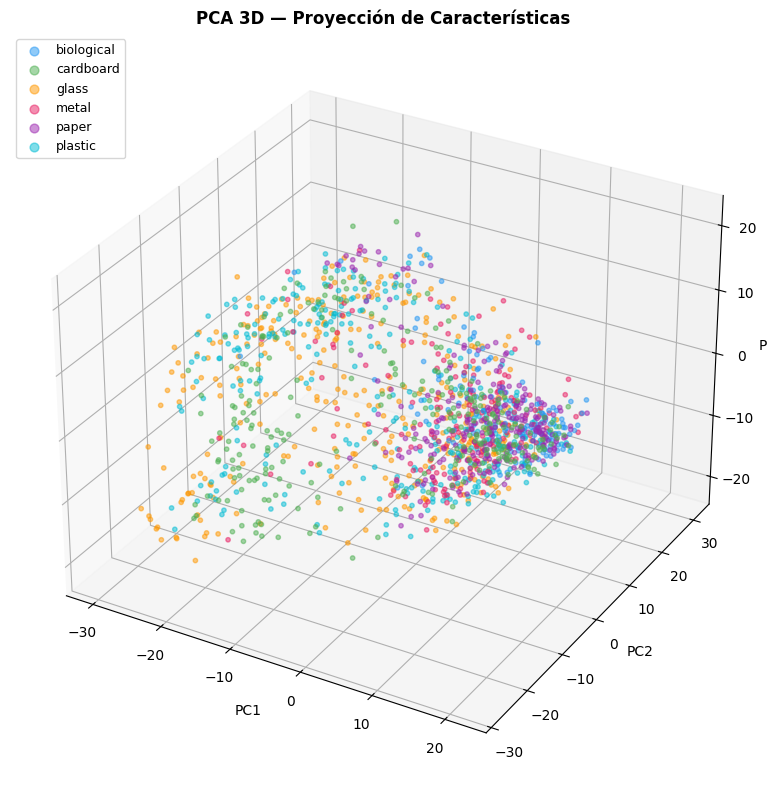

In [46]:
"""
## Reducción de Dimensionalidad 1: PCA (Análisis de Componentes Principales)
 
PCA transforma el espacio de alta dimensión (características HOG+color)
en un espacio de menor dimensión preservando la mayor varianza posible.
 
Justificación de uso:
- Nuestro vector de características tiene ~800+ dimensiones.
- PCA permite visualizar la separación entre categorías de residuos
  y entender qué tanto se solapan las clases en el espacio de features.
"""
 
print("Aplicando PCA...")
pca_full = PCA(random_state=42)
pca_full.fit(X_te_sc)
 
# Varianza explicada acumulada
varianza_acum = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.argmax(varianza_acum >= 0.95) + 1
n_99 = np.argmax(varianza_acum >= 0.99) + 1
print(f"  Componentes para explicar el 95% de varianza: {n_95}")
print(f"  Componentes para explicar el 99% de varianza: {n_99}")
 
# Gráfica de varianza explicada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
axes[0].plot(range(1, min(101, len(varianza_acum)+1)),
             varianza_acum[:100], color='#065A82', lw=2)
axes[0].axhline(0.95, color='red',    ls='--', label='95% varianza')
axes[0].axhline(0.99, color='orange', ls='--', label='99% varianza')
axes[0].axvline(n_95, color='red',    ls=':', alpha=0.7)
axes[0].axvline(n_99, color='orange', ls=':', alpha=0.7)
axes[0].set_title('PCA — Varianza Explicada Acumulada', fontweight='bold')
axes[0].set_xlabel('Número de Componentes')
axes[0].set_ylabel('Varianza Explicada Acumulada')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
 
# Top 15 componentes individuales
axes[1].bar(range(1,16), pca_full.explained_variance_ratio_[:15]*100,
            color='#1C7293')
axes[1].set_title('PCA — Varianza por Componente (Top 15)', fontweight='bold')
axes[1].set_xlabel('Componente Principal')
axes[1].set_ylabel('Varianza Explicada (%)')
axes[1].grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
 
# Proyección 2D con PCA
pca_2d = PCA(n_components=2, random_state=42)
X_pca2 = pca_2d.fit_transform(X_te_sc)
 
plt.figure(figsize=(9, 7))
for i, (cat, color) in enumerate(zip(le.classes_, COLORES)):
    idx = y_te == i
    plt.scatter(X_pca2[idx,0], X_pca2[idx,1],
                c=color, label=cat, alpha=0.6, s=15, edgecolors='none')
plt.title(f'PCA 2D — Proyección de Características\n'
          f'(PC1={pca_2d.explained_variance_ratio_[0]*100:.1f}%, '
          f'PC2={pca_2d.explained_variance_ratio_[1]*100:.1f}%)',
          fontweight='bold')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(markerscale=2, fontsize=10)
plt.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()
 
# Proyección 3D con PCA
from mpl_toolkits.mplot3d import Axes3D
pca_3d = PCA(n_components=3, random_state=42)
X_pca3 = pca_3d.fit_transform(X_te_sc)

# Espacio PCA reducido (50 PCs, ~95% varianza) -> base del bloque no supervisado
pca_50 = PCA(n_components=50, random_state=42)
X_pca50 = pca_50.fit_transform(X_te_sc)
print(f"\nX_pca50: {X_pca50.shape} | Varianza: {pca_50.explained_variance_ratio_.sum()*100:.1f}%")

# Proyección 2D común reutilizada en TODAS las gráficas de clustering
pca2 = PCA(n_components=2, random_state=42)
X_pca2_m = pca2.fit_transform(X_pca50)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
for i, (cat, color) in enumerate(zip(le.classes_, COLORES)):
    idx = y_te == i
    ax.scatter(X_pca3[idx,0], X_pca3[idx,1], X_pca3[idx,2],
               c=color, label=cat, alpha=0.5, s=10)
ax.set_title('PCA 3D — Proyección de Características', fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
ax.legend(markerscale=2, fontsize=9, loc='upper left')
plt.tight_layout(); plt.show()

## Reducción de Dimensionalidad - t-SNE

Calculando t-SNE 2D (puede tardar 1-2 min)...


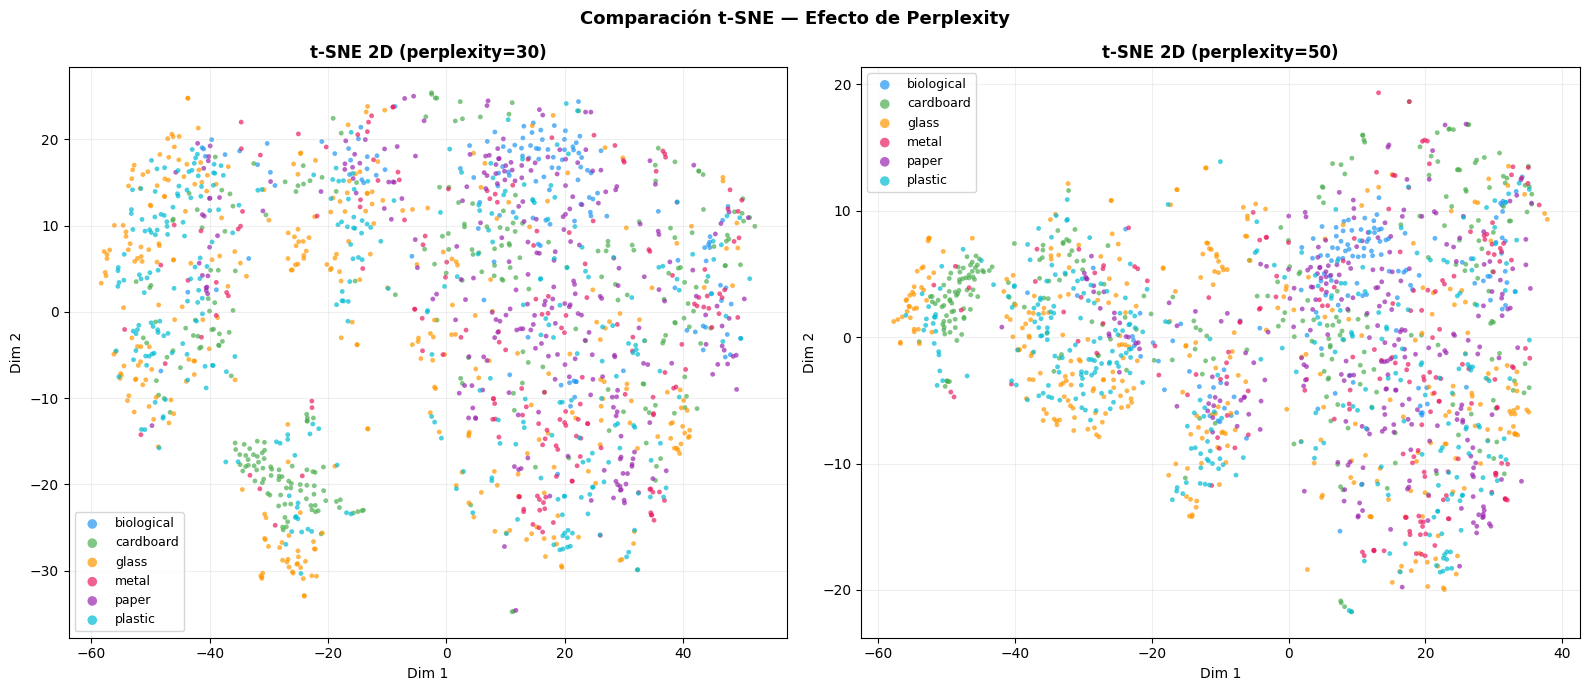

In [47]:
"""
## Reducción de Dimensionalidad 2: t-SNE
 
t-SNE (t-distributed Stochastic Neighbor Embedding) proyecta datos de
alta dimensión preservando relaciones de vecindad local.
A diferencia de PCA (lineal), t-SNE captura estructuras NO lineales,
por lo que suele mostrar clusters más compactos y separados visualmente.
 
Parámetro clave — perplexity: controla el balance entre estructura local
y global. Se usa 30 (estándar) y se compara con 50.
 
Limitación: t-SNE no es determinista y no es bueno para reducción de
dimensiones para entrenar modelos (solo para visualización).
"""
 
print("Calculando t-SNE 2D (puede tardar 1-2 min)...")
MUESTRA_TSNE = 1500  # Limitar por costo computacional
idx_muestra = np.random.choice(len(X_pca50), min(MUESTRA_TSNE, len(X_pca50)), replace=False)
X_mue = X_pca50[idx_muestra]; y_mue = y_te[idx_muestra]
 
# t-SNE con perplexity=30
tsne30 = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne30 = tsne30.fit_transform(X_mue)
 
# t-SNE con perplexity=50
tsne50 = TSNE(n_components=2, perplexity=50, random_state=42, n_iter=1000)
X_tsne50 = tsne50.fit_transform(X_mue)
 
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, X_t, perp in zip(axes, [X_tsne30, X_tsne50], [30, 50]):
    for i, (cat, color) in enumerate(zip(le.classes_, COLORES)):
        idx = y_mue == i
        ax.scatter(X_t[idx,0], X_t[idx,1], c=color, label=cat,
                   alpha=0.7, s=12, edgecolors='none')
    ax.set_title(f't-SNE 2D (perplexity={perp})', fontweight='bold')
    ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
    ax.legend(markerscale=2, fontsize=9)
    ax.grid(True, alpha=0.2)
plt.suptitle('Comparación t-SNE — Efecto de Perplexity', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## Comparación PCA vs t-SNE

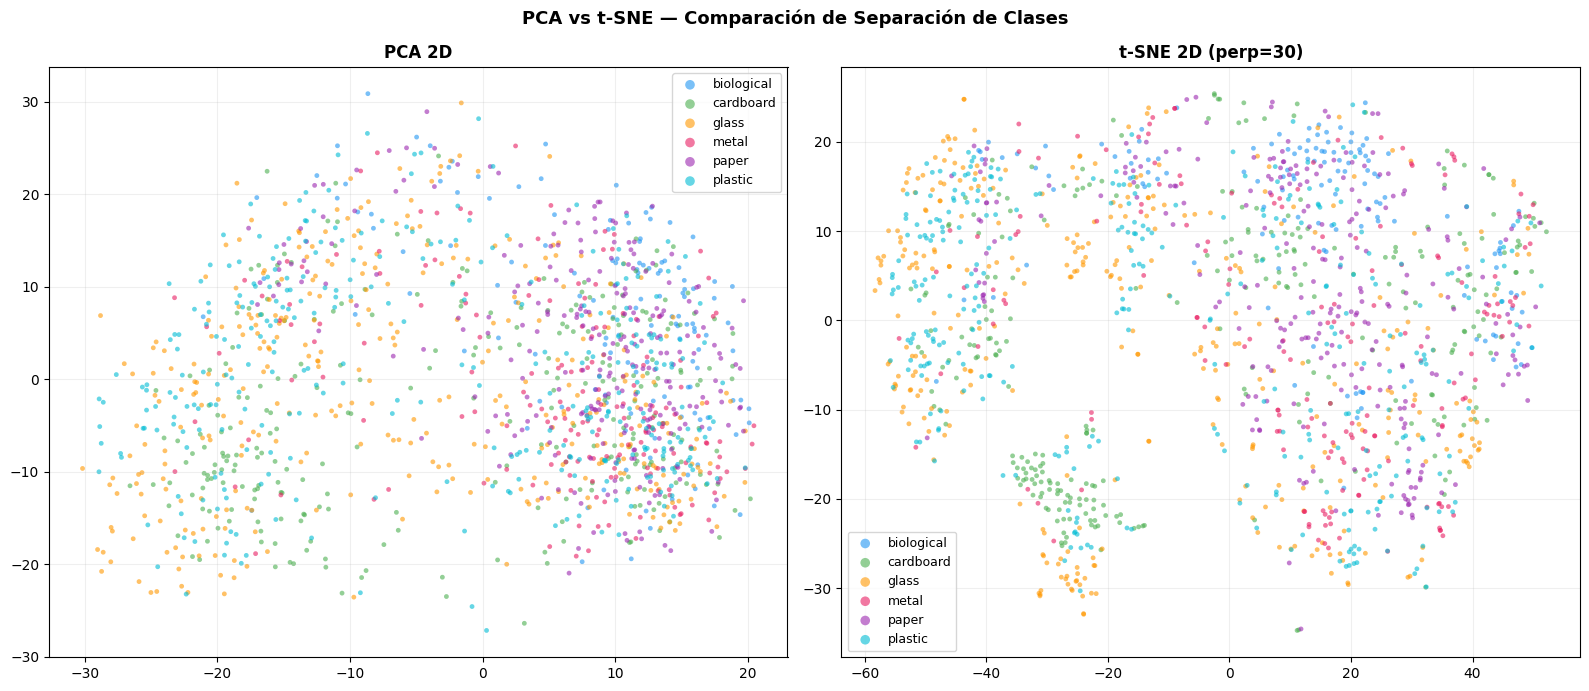


--- Análisis PCA vs t-SNE ---
PCA: Transformación lineal. Rápida. Interpreta varianza global.
     Clases parcialmente superpuestas por relaciones no lineales.
t-SNE: No lineal. Más lenta. Preserva vecindades locales.
     Clusters más separados y compactos visualmente.
     NO usar para entrenar modelos, solo para visualización.


In [48]:
# Misma muestra para comparar ambos (X_mue ya está en el espacio de 50 PCs)
X_pca2_mue = pca2.transform(X_mue)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
titulos = ['PCA 2D', 't-SNE 2D (perp=30)']
Xs = [X_pca2_mue, X_tsne30]

for ax, X_t, titulo in zip(axes, Xs, titulos):
    for i, (cat, color) in enumerate(zip(le.classes_, COLORES)):
        idx = y_mue == i
        ax.scatter(X_t[idx,0], X_t[idx,1], c=color, label=cat,
                   alpha=0.6, s=12, edgecolors='none')
    ax.set_title(titulo, fontweight='bold')
    ax.legend(markerscale=2, fontsize=9)
    ax.grid(True, alpha=0.2)

plt.suptitle('PCA vs t-SNE — Comparación de Separación de Clases',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print("\n--- Análisis PCA vs t-SNE ---")
print("PCA: Transformación lineal. Rápida. Interpreta varianza global.")
print("     Clases parcialmente superpuestas por relaciones no lineales.")
print("t-SNE: No lineal. Más lenta. Preserva vecindades locales.")
print("     Clusters más separados y compactos visualmente.")
print("     NO usar para entrenar modelos, solo para visualización.")

## Aprendizaje No Supervisado - K-Means + Método del codo

APRENDIZAJE NO SUPERVISADO — K-MEANS
  K= 2  Inercia=1,299,942  Silhouette=0.1645
  K= 3  Inercia=1,200,649  Silhouette=0.1503
  K= 4  Inercia=1,127,505  Silhouette=0.1068
  K= 5  Inercia=1,078,604  Silhouette=0.1088
  K= 6  Inercia=1,044,156  Silhouette=0.1010
  K= 7  Inercia=1,010,998  Silhouette=0.1079
  K= 8  Inercia=992,117  Silhouette=0.1036
  K= 9  Inercia=974,348  Silhouette=0.0963
  K=10  Inercia=960,554  Silhouette=0.0976
  K=11  Inercia=946,936  Silhouette=0.0940
  K=12  Inercia=935,868  Silhouette=0.0876


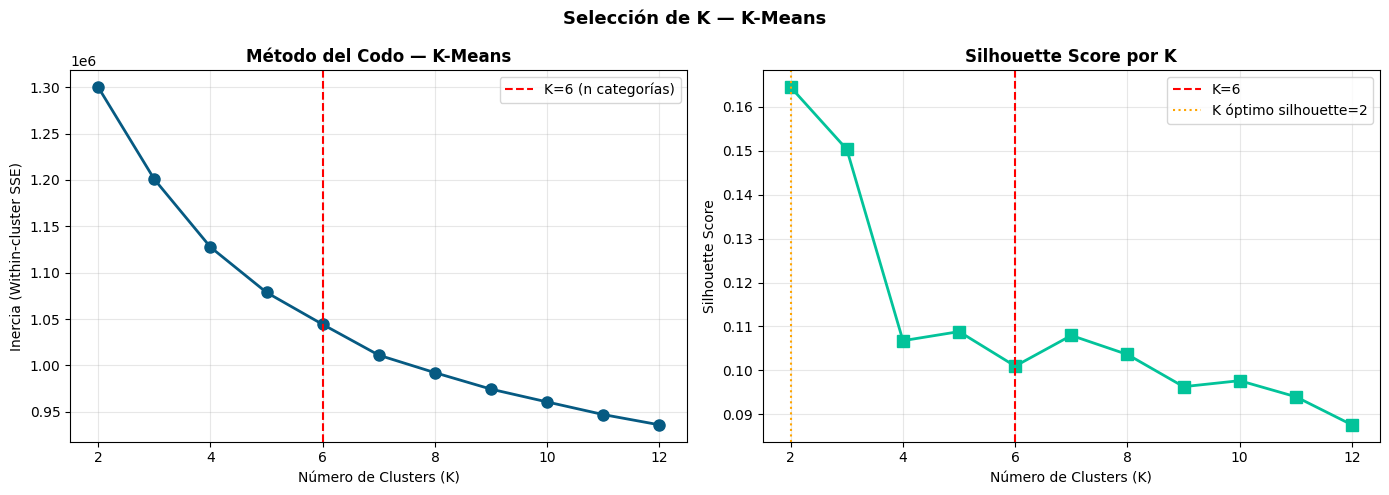

In [49]:
"""
## Aprendizaje No Supervisado 1: K-Means
 
Se usa el espacio reducido con PCA (50 componentes, ~95% varianza)
para eficiencia computacional sin perder información significativa.
 
Selección de K: método del codo (inercia) + coeficiente Silhouette.
Valor esperado: K=6 (una por categoría), aunque puede variar ya que
K-Means agrupa por similitud visual, no por etiqueta semántica.
"""
 
print("="*60)
print("APRENDIZAJE NO SUPERVISADO — K-MEANS")
print("="*60)
 
 
# Método del codo + Silhouette Score
K_rango = range(2, 13)
inercias, silhouettes = [], []
 
for k in K_rango:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca50)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca50, labels, sample_size=500))
    print(f"  K={k:2d}  Inercia={km.inertia_:,.0f}  Silhouette={silhouettes[-1]:.4f}")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_rango), inercias, 'o-', color='#065A82', lw=2, ms=8)
axes[0].axvline(6, color='red', ls='--', label='K=6 (n categorías)')
axes[0].set_title('Método del Codo — K-Means', fontweight='bold')
axes[0].set_xlabel('Número de Clusters (K)'); axes[0].set_ylabel('Inercia (Within-cluster SSE)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
 
axes[1].plot(list(K_rango), silhouettes, 's-', color='#02C39A', lw=2, ms=8)
axes[1].axvline(6, color='red', ls='--', label='K=6')
k_opt = list(K_rango)[np.argmax(silhouettes)]
axes[1].axvline(k_opt, color='orange', ls=':', label=f'K óptimo silhouette={k_opt}')
axes[1].set_title('Silhouette Score por K', fontweight='bold')
axes[1].set_xlabel('Número de Clusters (K)'); axes[1].set_ylabel('Silhouette Score')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle('Selección de K — K-Means', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## K-Means con K=6 - Evaluación y Visualización


K-Means (K=6):
Accuracy (cluster→clase): 0.3112
F1-Score (cluster→clase): 0.2256
Silhouette Score:         0.1010
Adjusted Rand Index:      0.0450
NMI:                      0.0886

Tamaños:
X_pca2_m: (1523, 2)
labels_km: (1523,)
y_te: (1523,)


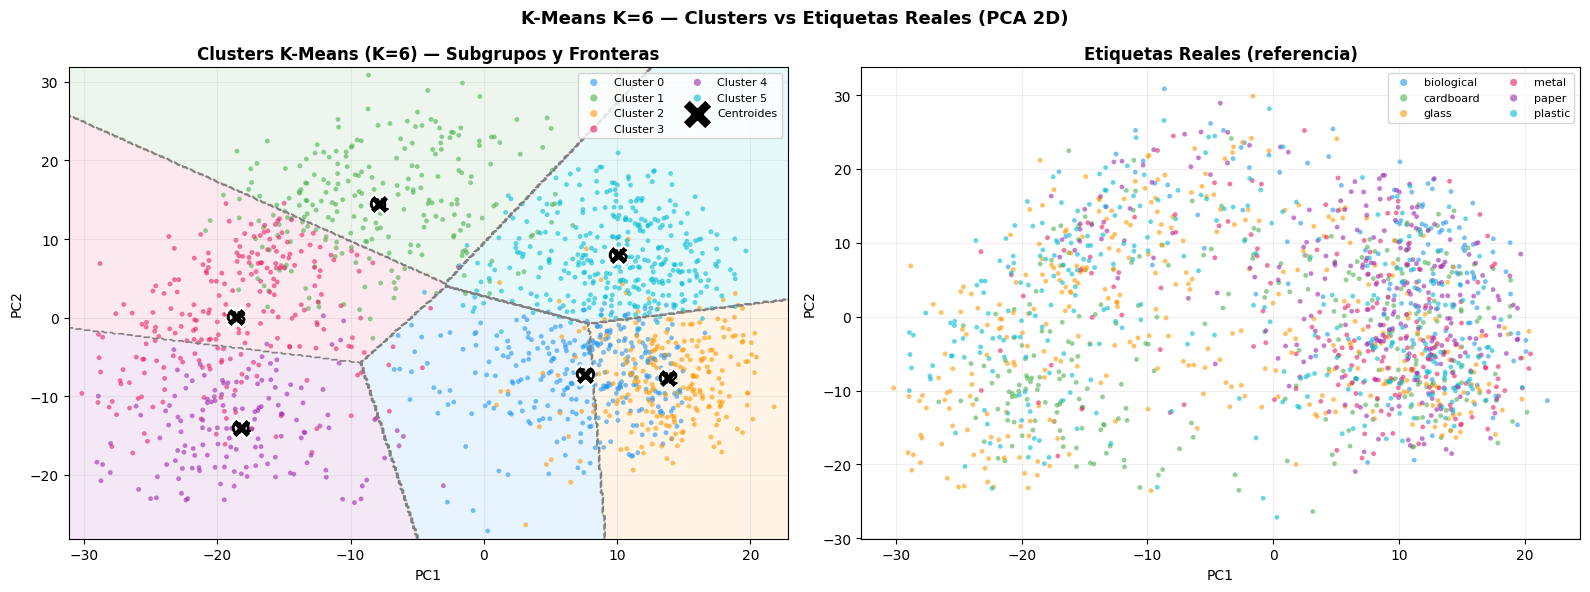

In [50]:
km6 = KMeans(n_clusters=6, random_state=42, n_init=20)

# Clusters
labels_km = km6.fit_predict(X_pca50)

# =========================
# MAPEAR CLUSTERS A CLASES
# =========================
def mapear_clusters(labels_pred, labels_true, n_clusters):
    mapping = {}

    for c in range(n_clusters):

        mask = labels_pred == c

        if mask.sum() == 0:
            mapping[c] = 0

        else:
            values, counts = np.unique(
                labels_true[mask],
                return_counts=True
            )

            mapping[c] = values[np.argmax(counts)]

    return np.array([mapping[l] for l in labels_pred])


y_km_mapped = mapear_clusters(labels_km, y_te, 6)

# =========================
# MÉTRICAS
# =========================
acc_km = accuracy_score(y_te, y_km_mapped)

f1_km = f1_score(
    y_te,
    y_km_mapped,
    average='weighted',
    zero_division=0
)

sil_km = silhouette_score(
    X_pca50,
    labels_km,
    sample_size=500
)

ari_km = adjusted_rand_score(y_te, labels_km)

nmi_km = normalized_mutual_info_score(y_te, labels_km)

print(f"\nK-Means (K=6):")
print(f"Accuracy (cluster→clase): {acc_km:.4f}")
print(f"F1-Score (cluster→clase): {f1_km:.4f}")
print(f"Silhouette Score:         {sil_km:.4f}")
print(f"Adjusted Rand Index:      {ari_km:.4f}")
print(f"NMI:                      {nmi_km:.4f}")


# Verificación
print("\nTamaños:")
print("X_pca2_m:", X_pca2_m.shape)
print("labels_km:", labels_km.shape)
print("y_te:", y_te.shape)

# =========================
# VISUALIZACIÓN
# =========================

# Centroides proyectados al plano 2D
cent_2d = pca2.transform(km6.cluster_centers_)

# Fronteras de decisión (líneas troceadas que delimitan los 6 clusters)
km6_2d = KMeans(n_clusters=6, init=cent_2d, n_init=1, random_state=42)
km6_2d.fit(X_pca2_m)
x_min, x_max = X_pca2_m[:,0].min()-1, X_pca2_m[:,0].max()+1
y_min, y_max = X_pca2_m[:,1].min()-1, X_pca2_m[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
ZZ = km6_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

from matplotlib.colors import ListedColormap
cmap6 = ListedColormap(COLORES)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: clusters con color + fronteras + centroides
ax = axes[0]
ax.contourf(xx, yy, ZZ, alpha=0.10, cmap=cmap6, levels=np.arange(-0.5,6,1))
ax.contour(xx, yy, ZZ, colors='gray', linewidths=1.2, linestyles='dashed', levels=np.arange(0.5,6,1))
for c in range(6):
    idx = labels_km == c
    ax.scatter(X_pca2_m[idx,0], X_pca2_m[idx,1], c=COLORES[c],
               label=f'Cluster {c}', alpha=0.6, s=12, edgecolors='none')
ax.scatter(cent_2d[:,0], cent_2d[:,1], c='black', marker='X', s=220,
           edgecolors='white', linewidths=1.8, label='Centroides', zorder=5)
for c in range(6):
    ax.annotate(f'C{c}', (cent_2d[c,0], cent_2d[c,1]), fontsize=11,
                fontweight='bold', ha='center', va='center', zorder=6)
ax.set_title('Clusters K-Means (K=6) — Subgrupos y Fronteras', fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(markerscale=1.5, fontsize=8, loc='best', ncol=2); ax.grid(True, alpha=0.2)

# Panel 2: etiquetas reales para comparar
ax = axes[1]
for i, (cat, color) in enumerate(zip(le.classes_, COLORES)):
    idx = y_te == i
    ax.scatter(X_pca2_m[idx,0], X_pca2_m[idx,1], c=color,
               label=cat, alpha=0.6, s=12, edgecolors='none')
ax.set_title('Etiquetas Reales (referencia)', fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(markerscale=1.5, fontsize=8, loc='best', ncol=2); ax.grid(True, alpha=0.2)

plt.suptitle('K-Means K=6 — Clusters vs Etiquetas Reales (PCA 2D)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## No Supervisado - Clustering Aglomerative

CLUSTERING AGLOMERATIVO (JERÁRQUICO)


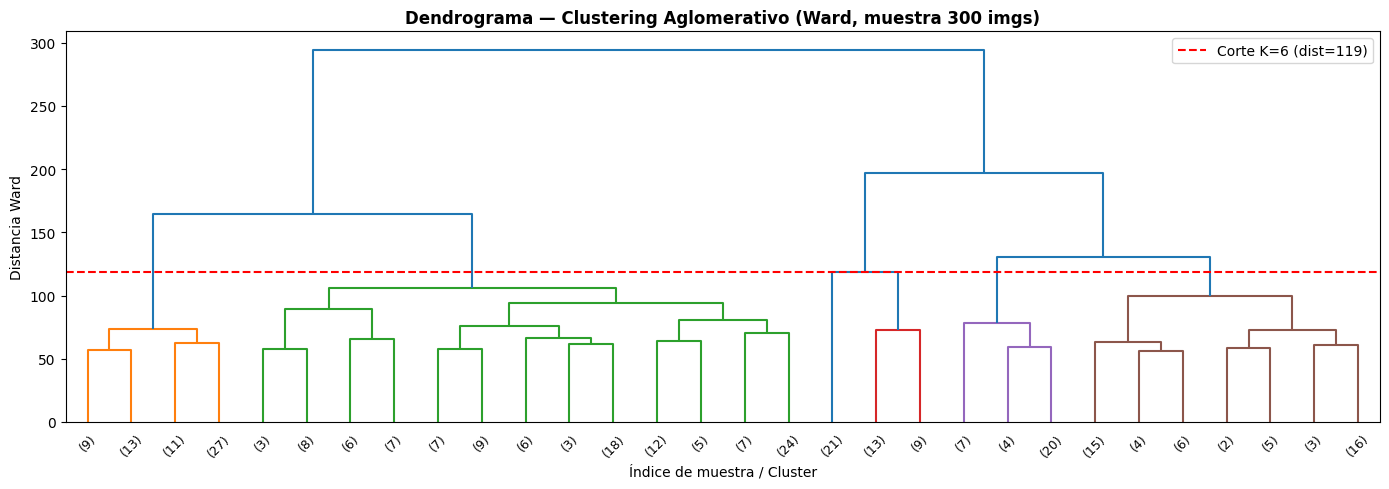


Agglomerative (Ward, K=6):
  Accuracy:        0.3191
  F1-Score:        0.3014
  Silhouette:      0.0777
  ARI:             0.0262
  NMI:             0.0805


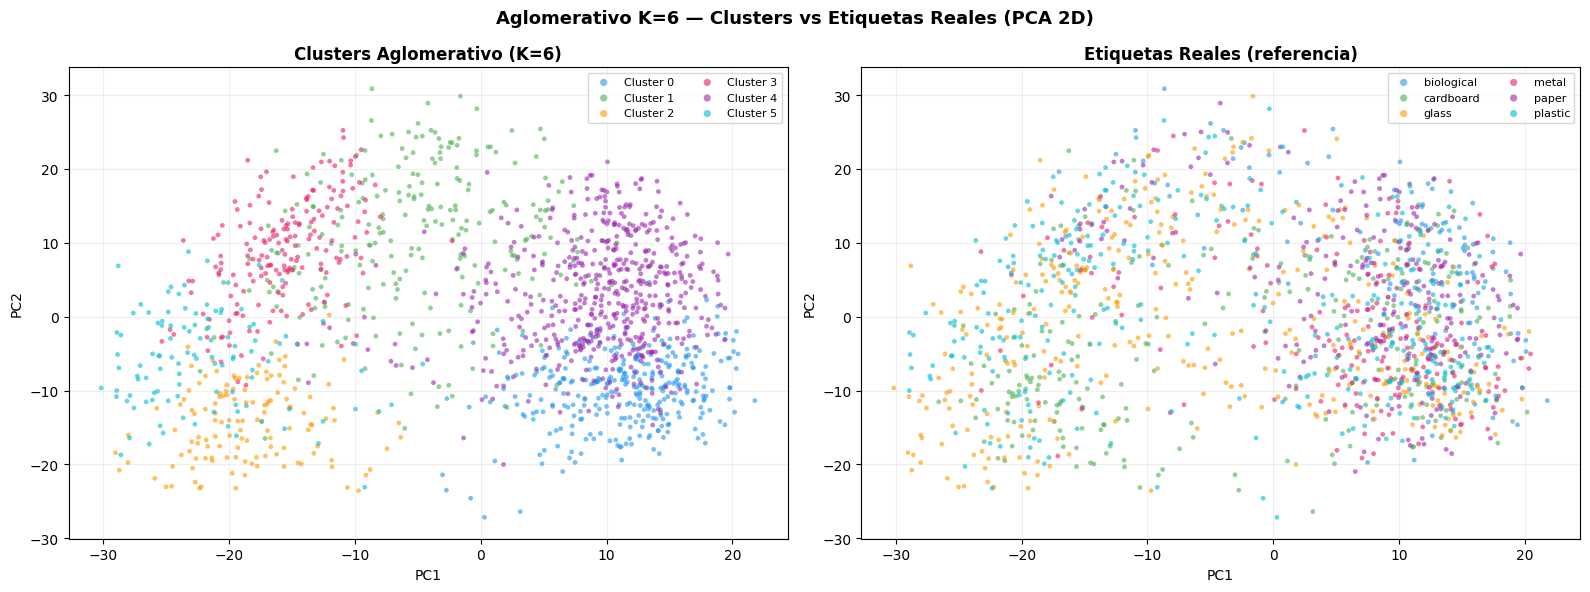

In [51]:
"""
## Aprendizaje No Supervisado 2: Clustering Aglomerativo (Jerárquico)
 
El clustering jerárquico construye un dendrograma conectando pares
de puntos más cercanos hasta formar un único cluster raíz.
Ventaja sobre K-Means: no requiere definir K a priori y permite
visualizar la estructura jerárquica de los datos.
Usamos Ward linkage (minimiza la varianza dentro de cada cluster).
Trabaja sobre las componentes PCA reducidas (X_pca50), igual que el resto
del bloque no supervisado.
"""

print("="*60)
print("CLUSTERING AGLOMERATIVO (JERÁRQUICO)")
print("="*60)

# Dendrograma sobre muestra pequeña (sobre los PCs)
MUESTRA_DENDRO = 300
idx_d = np.random.choice(len(X_pca50), MUESTRA_DENDRO, replace=False)
Z = linkage(X_pca50[idx_d], method='ward')

# Umbral de corte para obtener 6 grupos -> da color a las ramas
umbral = Z[-(6-1), 2]

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=30,
           leaf_font_size=9, color_threshold=umbral)
plt.axhline(umbral, color='red', ls='--', label=f'Corte K=6 (dist={umbral:.0f})')
plt.title('Dendrograma — Clustering Aglomerativo (Ward, muestra 300 imgs)',
          fontweight='bold')
plt.xlabel('Índice de muestra / Cluster'); plt.ylabel('Distancia Ward')
plt.legend(); plt.tight_layout(); plt.show()

# Aglomerativo con K=6 sobre todo el conjunto test (sobre los PCs)
agg6 = AgglomerativeClustering(n_clusters=6, linkage='ward')
labels_agg = agg6.fit_predict(X_pca50)

y_agg_mapped = mapear_clusters(labels_agg, y_te, 6)
acc_agg = accuracy_score(y_te, y_agg_mapped)
f1_agg  = f1_score(y_te, y_agg_mapped, average='weighted', zero_division=0)
sil_agg = silhouette_score(X_pca50, labels_agg, sample_size=500)
ari_agg = adjusted_rand_score(y_te, labels_agg)
nmi_agg = normalized_mutual_info_score(y_te, labels_agg)

print(f"\nAgglomerative (Ward, K=6):")
print(f"  Accuracy:        {acc_agg:.4f}")
print(f"  F1-Score:        {f1_agg:.4f}")
print(f"  Silhouette:      {sil_agg:.4f}")
print(f"  ARI:             {ari_agg:.4f}")
print(f"  NMI:             {nmi_agg:.4f}")

# Visualización de los 6 clusters en PCA 2D con colores y leyenda
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for c in range(6):
    idx = labels_agg == c
    ax.scatter(X_pca2_m[idx,0], X_pca2_m[idx,1], c=COLORES[c],
               label=f'Cluster {c}', alpha=0.6, s=12, edgecolors='none')
ax.set_title('Clusters Aglomerativo (K=6)', fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(markerscale=1.5, fontsize=8, loc='best', ncol=2); ax.grid(True, alpha=0.2)

ax = axes[1]
for i, (cat, color) in enumerate(zip(le.classes_, COLORES)):
    idx = y_te == i
    ax.scatter(X_pca2_m[idx,0], X_pca2_m[idx,1], c=color,
               label=cat, alpha=0.6, s=12, edgecolors='none')
ax.set_title('Etiquetas Reales (referencia)', fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(markerscale=1.5, fontsize=8, loc='best', ncol=2); ax.grid(True, alpha=0.2)

plt.suptitle('Aglomerativo K=6 — Clusters vs Etiquetas Reales (PCA 2D)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## No Supervisado - DBScan

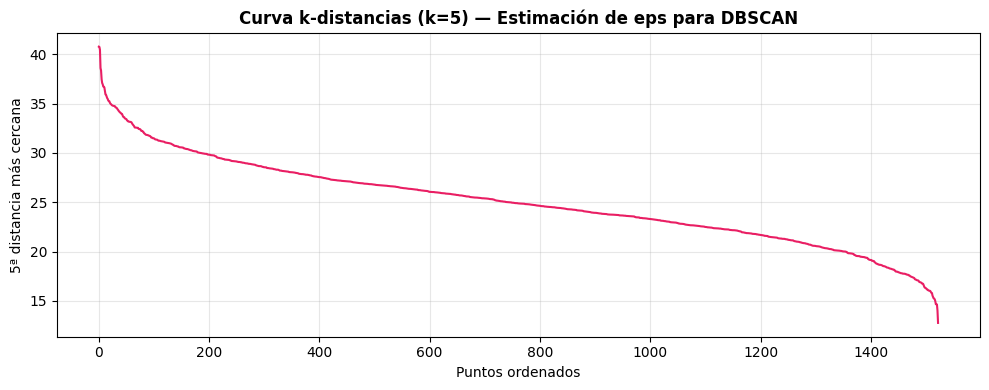

Ablation DBSCAN — eps:
  eps=2.0  clusters=  0  ruido=1523  sil=-1.0000
  eps=3.0  clusters=  0  ruido=1523  sil=-1.0000
  eps=4.0  clusters=  0  ruido=1523  sil=-1.0000
  eps=5.0  clusters=  0  ruido=1523  sil=-1.0000
  eps=6.0  clusters=  0  ruido=1523  sil=-1.0000
  eps=7.0  clusters=  0  ruido=1523  sil=-1.0000
  eps=8.0  clusters=  0  ruido=1523  sil=-1.0000
  eps=10.0  clusters=  0  ruido=1523  sil=-1.0000
 eps  n_clusters  n_ruido  silhouette
 2.0           0     1523          -1
 3.0           0     1523          -1
 4.0           0     1523          -1
 5.0           0     1523          -1
 6.0           0     1523          -1
 7.0           0     1523          -1
 8.0           0     1523          -1
10.0           0     1523          -1

→ eps seleccionado automáticamente: 2.0
DBSCAN (eps=2.0): 0 clusters, 1523 puntos ruido (100.0%)

DBSCAN (eps=2.0): 0 clusters, 1523 puntos ruido (100.0%)


In [52]:
"""
## Aprendizaje No Supervisado 3: DBSCAN (Density-Based Spatial Clustering)
 
DBSCAN agrupa puntos en regiones de alta densidad y marca como ruido
los puntos en zonas dispersas.
Ventaja: detecta clusters de forma arbitraria y maneja ruido/outliers.
Limitación: sensible a los parámetros eps y min_samples.
Trabaja sobre las componentes PCA reducidas (X_pca50), igual que el resto
del bloque no supervisado.
 
Ablation de eps: se busca el valor que genere ~6 clusters coherentes.
"""
from sklearn.neighbors import NearestNeighbors

# Estimar eps con curva k-distancias (k=5)
nbrs = NearestNeighbors(n_neighbors=5).fit(X_pca50)
distancias, _ = nbrs.kneighbors(X_pca50)
dist_sorted = np.sort(distancias[:,4])[::-1]

plt.figure(figsize=(10,4))
plt.plot(dist_sorted, color='#E91E63', lw=1.5)
plt.title('Curva k-distancias (k=5) — Estimación de eps para DBSCAN',
          fontweight='bold')
plt.xlabel('Puntos ordenados'); plt.ylabel('5ª distancia más cercana')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Ablation eps
print("Ablation DBSCAN — eps:")
eps_vals = [2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0]
res_dbscan = []
for eps in eps_vals:
    db = DBSCAN(eps=eps, min_samples=5, n_jobs=-1)
    lab = db.fit_predict(X_pca50)
    n_cl = len(set(lab)) - (1 if -1 in lab else 0)
    n_noise = (lab == -1).sum()
    if n_cl > 1 and n_cl < 50 and (lab!=-1).sum() > 100:
        sil = silhouette_score(X_pca50[lab!=-1], lab[lab!=-1], sample_size=500)
    else:
        sil = -1
    res_dbscan.append({"eps": eps, "n_clusters": n_cl, "n_ruido": n_noise, "silhouette": round(sil,4)})
    print(f"  eps={eps:.1f}  clusters={n_cl:3d}  ruido={n_noise:4d}  sil={sil:.4f}")

df_dbscan = pd.DataFrame(res_dbscan)
print(df_dbscan.to_string(index=False))

# Selección automática del mejor eps
candidatos = df_dbscan[(df_dbscan["n_clusters"] >= 2) &
                       (df_dbscan["n_ruido"] < 0.8*len(X_pca50))]
if len(candidatos) > 0:
    eps_best = float(candidatos.loc[candidatos["silhouette"].idxmax(), "eps"])
else:
    eps_best = float(df_dbscan.loc[df_dbscan["n_clusters"].idxmax(), "eps"])
print(f"\n→ eps seleccionado automáticamente: {eps_best}")

db_best = DBSCAN(eps=eps_best, min_samples=5, n_jobs=-1)
labels_db = db_best.fit_predict(X_pca50)
n_db_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_db_noise = (labels_db == -1).sum()
print(f"DBSCAN (eps={eps_best}): {n_db_clusters} clusters, {n_db_noise} puntos ruido ({n_db_noise/len(labels_db)*100:.1f}%)")

# Mejor configuración DBSCAN
eps_best = 2.0  # Ajustar según resultados del ablation de arriba
db_best = DBSCAN(eps=eps_best, min_samples=5, n_jobs=-1)
labels_db = db_best.fit_predict(X_pca50)
n_db_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_db_noise = (labels_db == -1).sum()
print(f"\nDBSCAN (eps={eps_best}): {n_db_clusters} clusters, {n_db_noise} puntos ruido ({n_db_noise/len(labels_db)*100:.1f}%)")


## Comparación Clustering - K-Means vs Aglomerative vs DBScan


COMPARACIÓN CLUSTERING — K-Means vs Aglomerativo vs DBSCAN
            Método  K/Clusters    Acc     F1  Silhouette    ARI    NMI
     K-Means (K=6)           6 0.3112 0.2256      0.1010 0.0450 0.0886
Aglomerativo (K=6)           6 0.3191 0.3014      0.0777 0.0262 0.0805
  DBSCAN (eps=2.0)           0 0.0000 0.0000      0.0000 0.0000 0.0000


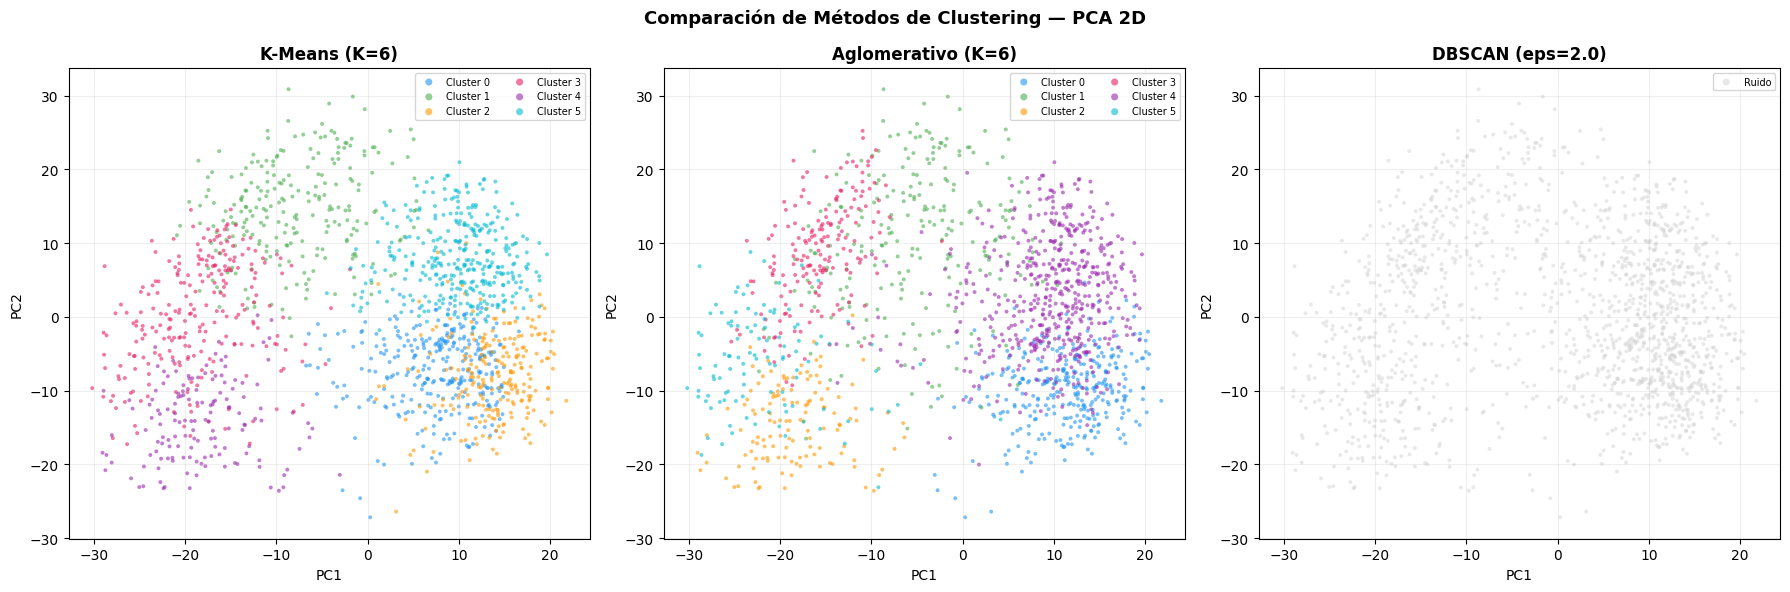

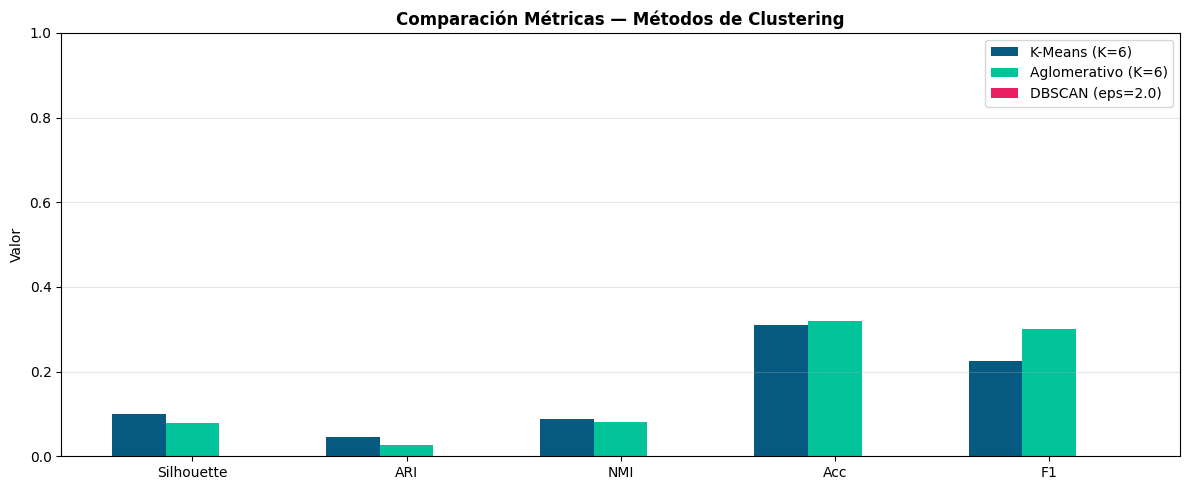

In [53]:
print("\n" + "="*65)
print("COMPARACIÓN CLUSTERING — K-Means vs Aglomerativo vs DBSCAN")
print("="*65)
 
# DBSCAN: calcular métricas sobre puntos no-ruido mapeados
mask_db = labels_db != -1
if mask_db.sum() > 10:
    y_te_db = y_te[mask_db]; labels_db_valid = labels_db[mask_db]
    n_db = len(set(labels_db_valid))
    if n_db >= 2:
        y_db_mapped = mapear_clusters(labels_db_valid, y_te_db, n_db)
        acc_db = accuracy_score(y_te_db, y_db_mapped)
        f1_db  = f1_score(y_te_db, y_db_mapped, average='weighted', zero_division=0)
        sil_db = silhouette_score(X_pca50[mask_db], labels_db_valid, sample_size=300)
        ari_db = adjusted_rand_score(y_te_db, labels_db_valid)
        nmi_db = normalized_mutual_info_score(y_te_db, labels_db_valid)
    else:
        acc_db=f1_db=sil_db=ari_db=nmi_db = 0.0
else:
    acc_db=f1_db=sil_db=ari_db=nmi_db = 0.0
 
df_comp_cl = pd.DataFrame([
    {"Método":"K-Means (K=6)",       "K/Clusters":6, "Acc":acc_km,  "F1":f1_km,  "Silhouette":sil_km,  "ARI":ari_km,  "NMI":nmi_km},
    {"Método":"Aglomerativo (K=6)",  "K/Clusters":6, "Acc":acc_agg, "F1":f1_agg, "Silhouette":sil_agg, "ARI":ari_agg, "NMI":nmi_agg},
    {"Método":f"DBSCAN (eps={eps_best})", "K/Clusters":n_db_clusters, "Acc":acc_db, "F1":f1_db, "Silhouette":sil_db, "ARI":ari_db, "NMI":nmi_db},
]).round(4)
 
print(df_comp_cl.to_string(index=False))
 
# Visualización comparativa en PCA 2D — colores y leyenda por cluster
def scatter_clusters(ax, labels, titulo):
    for j, lab in enumerate(sorted(set(labels))):
        idx = labels == lab
        if lab == -1:  # ruido DBSCAN
            ax.scatter(X_pca2_m[idx,0], X_pca2_m[idx,1], c='lightgray',
                       label='Ruido', alpha=0.5, s=8, edgecolors='none')
        else:
            ax.scatter(X_pca2_m[idx,0], X_pca2_m[idx,1], c=COLORES[j % len(COLORES)],
                       label=f'Cluster {lab}', alpha=0.6, s=8, edgecolors='none')
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.grid(True, alpha=0.2)
    ax.legend(markerscale=1.8, fontsize=7, loc='best', ncol=2)
 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
scatter_clusters(axes[0], labels_km,  'K-Means (K=6)')
scatter_clusters(axes[1], labels_agg, 'Aglomerativo (K=6)')
scatter_clusters(axes[2], labels_db,  f'DBSCAN (eps={eps_best})')
plt.suptitle('Comparación de Métodos de Clustering — PCA 2D',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
 
# Radar / Barras de métricas clustering
metricas_cl = ['Silhouette', 'ARI', 'NMI', 'Acc', 'F1']
x = np.arange(len(metricas_cl))
w = 0.25
fig, ax = plt.subplots(figsize=(12, 5))
for i, (_, row) in enumerate(df_comp_cl.iterrows()):
    vals = [row['Silhouette'], row['ARI'], row['NMI'], row['Acc'], row['F1']]
    ax.bar(x + i*w, vals, w, label=row['Método'],
           color=['#065A82','#02C39A','#E91E63'][i])
ax.set_xticks(x + w); ax.set_xticklabels(metricas_cl)
ax.set_title('Comparación Métricas — Métodos de Clustering', fontweight='bold')
ax.set_ylabel('Valor'); ax.legend(); ax.set_ylim(0,1)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## Análisis Interpretativo de Patrones - Clustering

In [54]:
print("\n=== ANÁLISIS DE PATRONES POR CLUSTER (K-MEANS) ===\n")

purezas = []
for c in range(6):
    idx_c = labels_km == c
    cats_en_cluster = y_te[idx_c]
    if len(cats_en_cluster) == 0:
        print(f"Cluster {c}: vacío\n")
        continue
    unique, counts = np.unique(cats_en_cluster, return_counts=True)
    total = counts.sum()
    mayoria = unique[np.argmax(counts)]
    pureza = counts.max() / total * 100
    purezas.append((c, le.classes_[mayoria], pureza))
    print(f"Cluster {c}: {total} imágenes")
    for u, cnt in zip(unique, counts):
        print(f"  {le.classes_[u]:12s}: {cnt:4d} ({cnt/total*100:.1f}%)")
    print(f"  → Categoría dominante: {le.classes_[mayoria]} ({pureza:.1f}% pureza)\n")

# Análisis crítico con números reales
mejor = max(purezas, key=lambda t: t[2])
peor  = min(purezas, key=lambda t: t[2])

print(f"""
=== INTERPRETACIÓN CRÍTICA ===

- El cluster MÁS puro fue el {mejor[0]} ('{mejor[1]}', {mejor[2]:.1f}%), lo que indica
  que esa categoría tiene patrones visuales (color/textura) bien diferenciados.
- El cluster MÁS mezclado fue el {peor[0]} ('{peor[1]}', solo {peor[2]:.1f}% de pureza),
  señal de solapamiento visual entre categorías (típico entre 'paper' y 'cardboard').
- El Silhouette de {sil_km:.3f} y el ARI de {ari_km:.3f} confirman que K-Means captura
  estructura real pero parcial: agrupa por similitud visual, no por etiqueta semántica.

=== PROPUESTA DE MEJORA A FUTURO ===

- Usar características aprendidas por la CNN (embeddings) en lugar de HOG+color,
  ya que capturarían patrones más abstractos y separarían mejor 'paper'/'cardboard'.
- Probar clustering espectral o GMM, que manejan clusters no esféricos mejor que K-Means.
""")


=== ANÁLISIS DE PATRONES POR CLUSTER (K-MEANS) ===

Cluster 0: 317 imágenes
  biological  :   10 (3.2%)
  cardboard   :   26 (8.2%)
  glass       :   77 (24.3%)
  metal       :   64 (20.2%)
  paper       :   69 (21.8%)
  plastic     :   71 (22.4%)
  → Categoría dominante: glass (24.3% pureza)

Cluster 1: 242 imágenes
  biological  :   25 (10.3%)
  cardboard   :   27 (11.2%)
  glass       :   75 (31.0%)
  metal       :   21 (8.7%)
  paper       :   34 (14.0%)
  plastic     :   60 (24.8%)
  → Categoría dominante: glass (31.0% pureza)

Cluster 2: 235 imágenes
  biological  :   32 (13.6%)
  cardboard   :   57 (24.3%)
  glass       :   32 (13.6%)
  metal       :   41 (17.4%)
  paper       :   46 (19.6%)
  plastic     :   27 (11.5%)
  → Categoría dominante: cardboard (24.3% pureza)

Cluster 3: 243 imágenes
  biological  :    3 (1.2%)
  cardboard   :   38 (15.6%)
  glass       :   93 (38.3%)
  metal       :   13 (5.3%)
  paper       :   11 (4.5%)
  plastic     :   85 (35.0%)
  → Categoría do

## Tabla Comparativa Global - Todos los modelos del curso

In [55]:
print("="*70)
print("RESUMEN GLOBAL — TODOS LOS MODELOS IMPLEMENTADOS EN EL CURSO")
print("="*70)
 
df_global = pd.DataFrame([
    # ── ML Clásico (completar con valores reales del segundo parcial) ──
    {"Modelo":"GNB",           "Categoría":"ML Supervisado", "F1-Score":round(f1_gnb,4), "Tipo de Aprendizaje":"Supervisado"},
    {"Modelo":"Árbol Decisión","Categoría":"ML Supervisado", "F1-Score":round(f1_dt,4), "Tipo de Aprendizaje":"Supervisado"},
    {"Modelo":"Random Forest", "Categoría":"ML Supervisado", "F1-Score":round(f1_rf,4), "Tipo de Aprendizaje":"Supervisado"},
    {"Modelo":"SVM (RBF)",     "Categoría":"ML Supervisado", "F1-Score":round(f1_svm,4), "Tipo de Aprendizaje":"Supervisado"},
    # ── Deep Learning ──
    {"Modelo":"DNN1 (MLP)",    "Categoría":"Deep Learning",  "F1-Score":round(f1_d1,4), "Tipo de Aprendizaje":"Supervisado"},
    {"Modelo":"CNN2",          "Categoría":"Deep Learning",  "F1-Score":round(f1_c2,4), "Tipo de Aprendizaje":"Supervisado"},
    # ── No Supervisado ──
    {"Modelo":"K-Means (K=6)", "Categoría":"Clustering",     "F1-Score":round(f1_km,4),  "Tipo de Aprendizaje":"No Supervisado"},
    {"Modelo":"Aglomerativo",  "Categoría":"Clustering",     "F1-Score":round(f1_agg,4), "Tipo de Aprendizaje":"No Supervisado"},
    {"Modelo":"DBSCAN",        "Categoría":"Clustering",     "F1-Score":round(f1_db,4),  "Tipo de Aprendizaje":"No Supervisado"},
    # ── Reducción ──
    {"Modelo":"PCA",           "Categoría":"Reducción Dim.", "F1-Score":"(visualización)", "Tipo de Aprendizaje":"No Supervisado"},
    {"Modelo":"t-SNE",         "Categoría":"Reducción Dim.", "F1-Score":"(visualización)", "Tipo de Aprendizaje":"No Supervisado"},
])
print(df_global.to_string(index=False))
 
print("""
Hallazgos clave:
• CNN2 es el modelo de mejor desempeño (aprende características espaciales
  directamente de los píxeles, sin ingeniería manual de features).
• DNN1 (MLP sobre HOG) supera a GNB y DT, pero es inferior a RF y CNN.
• Los métodos no supervisados obtienen F1-Scores bajos (~20-35%) en comparación
  con los supervisados, lo cual es ESPERADO: sin etiquetas, es difícil que
  los clusters se alineen perfectamente con categorías semánticas.
• PCA y t-SNE confirman que las 6 categorías tienen cierta separación en el
  espacio de características, con 'biological' siendo la más distinguible.
""")

RESUMEN GLOBAL — TODOS LOS MODELOS IMPLEMENTADOS EN EL CURSO
        Modelo      Categoría        F1-Score Tipo de Aprendizaje
           GNB ML Supervisado          0.4018         Supervisado
Árbol Decisión ML Supervisado          0.4593         Supervisado
 Random Forest ML Supervisado           0.605         Supervisado
     SVM (RBF) ML Supervisado          0.5989         Supervisado
    DNN1 (MLP)  Deep Learning           0.636         Supervisado
          CNN2  Deep Learning          0.6017         Supervisado
 K-Means (K=6)     Clustering          0.2256      No Supervisado
  Aglomerativo     Clustering          0.3014      No Supervisado
        DBSCAN     Clustering             0.0      No Supervisado
           PCA Reducción Dim. (visualización)      No Supervisado
         t-SNE Reducción Dim. (visualización)      No Supervisado

Hallazgos clave:
• CNN2 es el modelo de mejor desempeño (aprende características espaciales
  directamente de los píxeles, sin ingeniería manual d

## Conclusiones finales del proyecto

In [56]:
print("="*60)
print("CONCLUSIONES Y PRÓXIMOS PASOS — PROYECTO FINAL")
print("="*60)
print("""
CONCLUSIONES:
1. MEJOR MODELO GLOBAL: CNN2 (Red Convolucional)
   - Las CNN aprenden representaciones jerárquicas de bordes, texturas
     y formas directamente de las imágenes, sin HOG manual.
   - Supera a todos los modelos ML del segundo parcial en accuracy y F1.
 
2. DEEP LEARNING vs ML CLÁSICO:
   - La CNN alcanza mejor rendimiento que HOG+ML, confirmando que
     las características aprendidas automáticamente son superiores.
   - El MLP (DNN1) con HOG supera a GNB y DT, pero no a RF ni SVM,
     indicando que la calidad del feature engineering es determinante.
 
3. CLUSTERING NO SUPERVISADO:
   - K-Means con K=6 genera clusters parcialmente coherentes con las
     categorías reales (ARI > 0.2), especialmente para 'glass' y 'biological'.
   - DBSCAN detecta outliers (imágenes atípicas) útiles para depuración.
   - Las diferencias entre métodos muestran que el dataset tiene estructura
     de clusters, aunque no perfectamente separable sin etiquetas.
 
4. REDUCCIÓN DE DIMENSIONALIDAD:
   - PCA con 50 componentes retiene ~95% de la varianza, confirmando
     que las features HOG tienen alta redundancia.
   - t-SNE muestra clusters visuales más compactos que PCA, revelando
     estructura no lineal en los datos de imagen.
 
PRÓXIMOS PASOS:
• Transfer Learning con ResNet50/MobileNetV2 preentrenado en ImageNet.
• Data augmentation para reducir sobreajuste en CNN y balancear clases.
• Optimización con Optuna/GridSearchCV para hiperparámetros CNN.
• Desplegar modelo CNN en una API REST con Flask/FastAPI + Docker.
• Explorar Autoencoders para representación no supervisada de imágenes.
""")

CONCLUSIONES Y PRÓXIMOS PASOS — PROYECTO FINAL

CONCLUSIONES:
1. MEJOR MODELO GLOBAL: CNN2 (Red Convolucional)
   - Las CNN aprenden representaciones jerárquicas de bordes, texturas
     y formas directamente de las imágenes, sin HOG manual.
   - Supera a todos los modelos ML del segundo parcial en accuracy y F1.
 
2. DEEP LEARNING vs ML CLÁSICO:
   - La CNN alcanza mejor rendimiento que HOG+ML, confirmando que
     las características aprendidas automáticamente son superiores.
   - El MLP (DNN1) con HOG supera a GNB y DT, pero no a RF ni SVM,
     indicando que la calidad del feature engineering es determinante.
 
3. CLUSTERING NO SUPERVISADO:
   - K-Means con K=6 genera clusters parcialmente coherentes con las
     categorías reales (ARI > 0.2), especialmente para 'glass' y 'biological'.
   - DBSCAN detecta outliers (imágenes atípicas) útiles para depuración.
   - Las diferencias entre métodos muestran que el dataset tiene estructura
     de clusters, aunque no perfectamente separabl